# **Ejercicio 3. Modelos de Deep Learning**

# *Planteamiento*

Contexto del problema: Para realizar predicción de series de tiempo, en la validación cruzada es
crucial considerar el orden natural del tiempo. Por ejemplo, la idea es predecir 7 días futuros, con
31 datos historicos de un mes, no lo contrario. No requerimos predecir el pasado, porque ya lo
conocemos. Con base en esto, es necesario construir manualmente una validación cruzada, que no
realice ninguna desorganización no natural, de los pliegues de entrenamiento, validación y prueba,
la cual esté en contra del orden temporal.

En cada uno de los siguientes ejercicios considere los siguientes pasos para construir sus modelos
predictivos. Debe realizar este procedimiento para las series: precio, retorno acumulado y volatilidad
para las diferentes ventanas (ω = 7, 14, 21, 28):

1. Defina funciones en Python para dividir el conjunto de datos en entrenamiento, validación
y test con base en la Figuras 2-4. Observe que en las tres figuras, aparecen ejemplos para
τ = 1, 2, 3, debe extenderlo hasta los diferentes horizontes: τ = 7, 14, 21, 28. Al final debe
unir las predicciones de cada punto para obtener el horizonte predicho completo de τ días,
luego debe compararlo con el resultado usando como output el y multivariado de τ días, tal
como se muestra en la Figura 5.

2. Nótese que TimeSeriesSplit no es una librería que funcione aquí, debido a que los pliegues
que entrega no coinciden con los de las Figuras 2-4 que son los solicitados en este examen,
por favor, no intente usarla, implemente sus propios pliegues. Al final de la construcción de
la función que entrega dichas divisiones, debe visualizarlas dentro de su JBook usando las
funciones de Python adecuadas para esto. El objetivo es verificar y confirmar que ha contruido
adecuadamente los pliegues de entrenamiento, validación y prueba y coinciden sus figuras con
las Figuras 2-5.

3. Para cada conjunto de parámetros, ajuste cada modelo predictivo en el conjunto de entrena-
miento, y dentro de sus iteraciones de busqueda, evalue su modelo en el conjunto de validación
usando las siguientes métricas: MAPE, MAE, RMSE. MSE y el R cuadrado.
4. Realice una tabla donde resuma para el residual (residuo en el conjunto de entrenamiento)
scores obtenidos y agregue además las respectivas pruebas de hipóteis para independencia
y normalidad. Para esto, usando Pandas construya una tabla con las siguientes columnas:
MAPE, MAE, RMSE, MSE, R2, LJung-Box test (p-value), Brock-Dechert-Scheinkman test (p-
value), Jarque-Bera (p-value) y agregue las figuras para Serie de residuos, QQPlot, ACF de
residuos.

5. Realice una tabla donde resuma los scores obtenidos por cada modelo en el conjunto de test
(error de predicción) y agregue además prueba de hipóteis para independencia. Para esto,
usando Pandas construya una tabla con las siguientes columnas: MAPE, MAE, RMSE, MSE,
R2, LJung-Box test (p-value), Brock-Dechert-Scheinkman test (p-value).

6. Considere conjuntos de validación y test de longitud τ = 7, 14, 21, 28 días. Para el conjunto
de entrenamiento considere todos los casos asociados con las combinaciones

$$
\dim \left( X_{\text{train}}^{(j)} \right) = \left( M_{\text{rows}}^{(j)}, N_{\text{cols}}^{(j)} \right) \quad \text{con} \quad M_{\text{rows}}^{(j)}, N_{\text{cols}}^{(j)} = 7, 14, 21, 28
$$

7. Realice las siguientes variaciones durante la construcción de su modelo y seleccione la que
entrega el menor error posible: Dropout: 0.2, 0.4, 0.6, 0.8; One layer and: (10,), (100,) (1000,)
(10000,) Neurons; Batchsize: 16, 32, 64, 128. Advertencia; Debe utilizar la librería Tensorflow-
Keras utilizada durante el curso de series de tiempo.

8. Para cada modelo obtenido dibuje la curva Runs vs Error/Score de entrenamiento historico del
modelo. En el eje y represente el Error/Score para los conjuntos de entrenamiento, validación
y test y en el eje x runs representa las iteraciones realizadas sobre cada j-ésimo pliegue de
entrenamiento, validación y prueba.
9. Dibuje tres boxplots (uno para cada set: train/validation/test) donde represente los errores
obtenidos en el ítem anterior en el eje y. Verifique que las medianas de los tres boxplots son
cercanas.
10. Dibuje para cada combinación la serie de tiempo original, el conjunto de validación, el con-
junto de test y la predicción del conjunto de test. Tenga en cuenta cada uno de los horizontes
τ = 7, 14, 21, 28
Los modelos que debe considerar para este ejercicio son los siguientes:
• MLP (Multilayer Perceptrón)
• RNN (Must investigate)
• LSTM (Long short-term memory)




# *Solución*

## Definición de funciones para la división de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import warnings

In [ ]:
#CARGUE DE DATOS Y LIMPIEZA.

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')
 
# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

In [ ]:
import statsmodels
print(statsmodels.__version__)

0.14.4


In [ ]:
pip install --upgrade statsmodels

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ELABORACIÓN Y DEFINICIÓN DE LAS VARIABLES.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox
# Correct import for jarque_bera
from statsmodels.stats.stattools import jarque_bera

def create_univariate_prediction_datasets(data, feature_col, target_col, input_window, forecast_horizon, tau=1):
    """
    Create training, validation, and test sets for univariate time series prediction
    that respects the temporal order of the data.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        The input dataframe containing the time series data
    feature_col : str
        Column name for the feature to use for prediction
    target_col : str
        Column name for the target variable to predict
    input_window : int
        Size of the input window (number of past observations)
    forecast_horizon : int
        Number of steps ahead to predict
    tau : int
        Specific horizon point to predict (1 for the first point, 2 for the second point, etc.)
        
    Returns:
    --------
    dict: Dictionary containing the training, validation, and test sets
    """
    if tau > forecast_horizon:
        raise ValueError(f"tau ({tau}) cannot be greater than forecast_horizon ({forecast_horizon})")
    
    feature_data = data[feature_col].values
    target_data = data[target_col].values
    
    # Lists to store our samples
    X_train_samples = []
    y_train_samples = []
    X_val_samples = []
    y_val_samples = []
    X_test_samples = []
    y_test_samples = []
    
    # Create the training, validation, and test sample indices
    for i in range(len(data) - input_window - forecast_horizon + 1):
        input_indices = list(range(i, i + input_window))
        target_index = i + input_window + tau - 1  # -1 because tau is 1-indexed
        
        if target_index < len(data):
            X = feature_data[input_indices]
            y = target_data[target_index]
            
            # Determine which set this sample belongs to
            if i % 7 == 0:  # Test set
                X_test_samples.append(X)
                y_test_samples.append(y)
            elif i % 7 == 1:  # Validation set
                X_val_samples.append(X)
                y_val_samples.append(y)
            else:  # Training set
                X_train_samples.append(X)
                y_train_samples.append(y)
    
    # Convert lists to numpy arrays
    X_train = np.array(X_train_samples)
    y_train = np.array(y_train_samples)
    X_val = np.array(X_val_samples)
    y_val = np.array(y_val_samples)
    X_test = np.array(X_test_samples)
    y_test = np.array(y_test_samples)
    
    # Reshape for deep learning models
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    
    return {
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val,
        'X_test': X_test,
        'y_test': y_test
    }

def create_multivariate_prediction_datasets(data, feature_col, target_col, input_window, forecast_horizon):
    """
    Create training, validation, and test sets for multivariate time series prediction
    that respects the temporal order of the data.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        The input dataframe containing the time series data
    feature_col : str
        Column name for the feature to use for prediction
    target_col : str
        Column name for the target variable to predict
    input_window : int
        Size of the input window (number of past observations)
    forecast_horizon : int
        Number of steps ahead to predict
        
    Returns:
    --------
    dict: Dictionary containing the training, validation, and test sets
    """
    feature_data = data[feature_col].values
    target_data = data[target_col].values
    
    # Lists to store our samples
    X_train_samples = []
    y_train_samples = []
    X_val_samples = []
    y_val_samples = []
    X_test_samples = []
    y_test_samples = []
    
    # Create the training, validation, and test sample indices
    for i in range(len(data) - input_window - forecast_horizon + 1):
        input_indices = list(range(i, i + input_window))
        target_indices = list(range(i + input_window, i + input_window + forecast_horizon))
        
        if max(target_indices) < len(data):
            X = feature_data[input_indices]
            y = target_data[target_indices]
            
            # Determine which set this sample belongs to
            if i % 7 == 0:  # Test set
                X_test_samples.append(X)
                y_test_samples.append(y)
            elif i % 7 == 1:  # Validation set
                X_val_samples.append(X)
                y_val_samples.append(y)
            else:  # Training set
                X_train_samples.append(X)
                y_train_samples.append(y)
    
    # Convert lists to numpy arrays
    X_train = np.array(X_train_samples)
    y_train = np.array(y_train_samples)
    X_val = np.array(X_val_samples)
    y_val = np.array(y_val_samples)
    X_test = np.array(X_test_samples)
    y_test = np.array(y_test_samples)
    
    # Reshape for deep learning models
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    
    return {
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val,
        'X_test': X_test,
        'y_test': y_test
    }

def plot_time_series_cv(data, feature_col, input_window, forecast_horizon, tau=1, n_splits=5):
    """
    Plot the time series cross-validation splits similar to the figures provided.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        The input dataframe containing the time series data
    feature_col : str
        Column name for the feature to use for prediction
    input_window : int
        Size of the input window (number of past observations)
    forecast_horizon : int
        Number of steps ahead to predict
    tau : int
        Specific horizon point to predict (1 for the first point, 2 for the second point, etc.)
    n_splits : int
        Number of splits to display
    """
    if tau > forecast_horizon:
        raise ValueError(f"tau ({tau}) cannot be greater than forecast_horizon ({forecast_horizon})")
    
    plt.figure(figsize=(12, 8))
    
    # Display specific splits
    for i in range(n_splits):
        row = i * 7  # Use multiples of 7 to match the test set pattern
        
        # Training set (red)
        train_start = row
        train_end = row + input_window
        plt.plot(range(train_start, train_end), [i*2] * (train_end - train_start), 'r-', linewidth=2)
        
        # Validation set (blue)
        val_start = row + 1
        val_end = val_start + input_window
        plt.plot(range(val_start, val_end), [i*2 + 0.5] * (val_end - val_start), 'b-', linewidth=2)
        
        # Test point (green)
        test_point = row + input_window + tau - 1
        plt.plot(test_point, i*2, 'go', markersize=10)
        
        # Dimensions for X and y
        plt.text(train_end + 1, i*2, f"dim(X_train) = ({input_window}, 1); dim(y_train) = (1,)", fontsize=10)
    
    plt.title(f'Time Series Cross-Validation Splits (tau = {tau})')
    plt.xlabel('Time Index')
    plt.ylabel('Split Number')
    plt.grid(True)
    plt.tight_layout()
    
    return plt.gcf()

def plot_multivariate_time_series_cv(data, feature_col, input_window, forecast_horizon, n_splits=5):
    """
    Plot the multivariate time series cross-validation splits similar to the figures provided.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        The input dataframe containing the time series data
    feature_col : str
        Column name for the feature to use for prediction
    input_window : int
        Size of the input window (number of past observations)
    forecast_horizon : int
        Number of steps ahead to predict
    n_splits : int
        Number of splits to display
    """
    plt.figure(figsize=(12, 8))
    
    # Display specific splits
    for i in range(n_splits):
        row = i * 7  # Use multiples of 7 to match the test set pattern
        
        # Training set (red)
        train_start = row
        train_end = row + input_window
        plt.plot(range(train_start, train_end), [i*2] * (train_end - train_start), 'r-', linewidth=2)
        
        # Forecast horizon (blue)
        horizon_start = train_end
        horizon_end = horizon_start + forecast_horizon
        plt.plot(range(horizon_start, horizon_end), [i*2] * (horizon_end - horizon_start), 'b-', linewidth=2)
        
        # Dimensions for X and y
        plt.text(train_end + 1, i*2, f"dim(X_train) = ({input_window}, 1); dim(y_train) = ({forecast_horizon},)", fontsize=10)
    
    plt.title(f'Multivariate Time Series Cross-Validation Splits (horizon = {forecast_horizon})')
    plt.xlabel('Time Index')
    plt.ylabel('Split Number')
    plt.grid(True)
    plt.tight_layout()
    
    return plt.gcf()

def calculate_metrics(y_true, y_pred):
    """
    Calculate various performance metrics for regression models.
    
    Parameters:
    -----------
    y_true : array-like
        True values
    y_pred : array-like
        Predicted values
        
    Returns:
    --------
    dict: Dictionary containing the calculated metrics
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # Calculate MAPE (handle zero values)
    epsilon = 1e-10  # Small value to avoid division by zero
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + epsilon))) * 100
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape
    }

def residual_tests(residuals):
    """
    Perform statistical tests on model residuals.
    
    Parameters:
    -----------
    residuals : array-like
        Model residuals (y_true - y_pred)
        
    Returns:
    --------
    dict: Dictionary containing the test results
    """
    # Ljung-Box test for autocorrelation
    lb_test = acorr_ljungbox(residuals, lags=10)
    lb_pvalue = lb_test[1][-1]  # Use the p-value from the highest lag
    
    # Jarque-Bera test for normality
    jb_test = jarque_bera(residuals)
    jb_pvalue = jb_test[1]
    
    # Alternative for BDS test (simple correlation test using ACF)
    from statsmodels.tsa.stattools import acf
    acf_result = acf(residuals, nlags=10)
    acf_mean = np.mean(np.abs(acf_result[1:]))  # Exclude lag 0
    
    return {
        'Ljung-Box p-value': lb_pvalue,
        'Jarque-Bera p-value': jb_pvalue,
        'ACF mean (absolute)': acf_mean  # Alternative to BDS
    }

def plot_residuals(residuals, title='Residuals'):
    """
    Plot the residuals, QQ plot, and ACF of residuals.
    
    Parameters:
    -----------
    residuals : array-like
        Model residuals (y_true - y_pred)
    title : str
        Title for the plot
        
    Returns:
    --------
    fig: Figure object
    """
    from scipy import stats
    from statsmodels.graphics.gofplots import qqplot
    from statsmodels.graphics.tsaplots import plot_acf
    
    fig, axs = plt.subplots(3, 1, figsize=(10, 12))
    
    # Residuals plot
    axs[0].plot(residuals, 'o-')
    axs[0].set_title(f'{title} Time Series')
    axs[0].set_xlabel('Index')
    axs[0].set_ylabel('Residual')
    axs[0].grid(True)
    
    # QQ plot
    qqplot(residuals, line='s', ax=axs[1])
    axs[1].set_title(f'{title} QQ Plot')
    
    # ACF plot
    plot_acf(residuals, lags=20, ax=axs[2])
    axs[2].set_title(f'{title} Autocorrelation')
    
    plt.tight_layout()
    return fig

Univariate datasets (tau=1) shapes:
X_train shape: (3555, 14, 1)
y_train shape: (3555,)
X_val shape: (712, 14, 1)
y_val shape: (712,)
X_test shape: (712, 14, 1)
y_test shape: (712,)


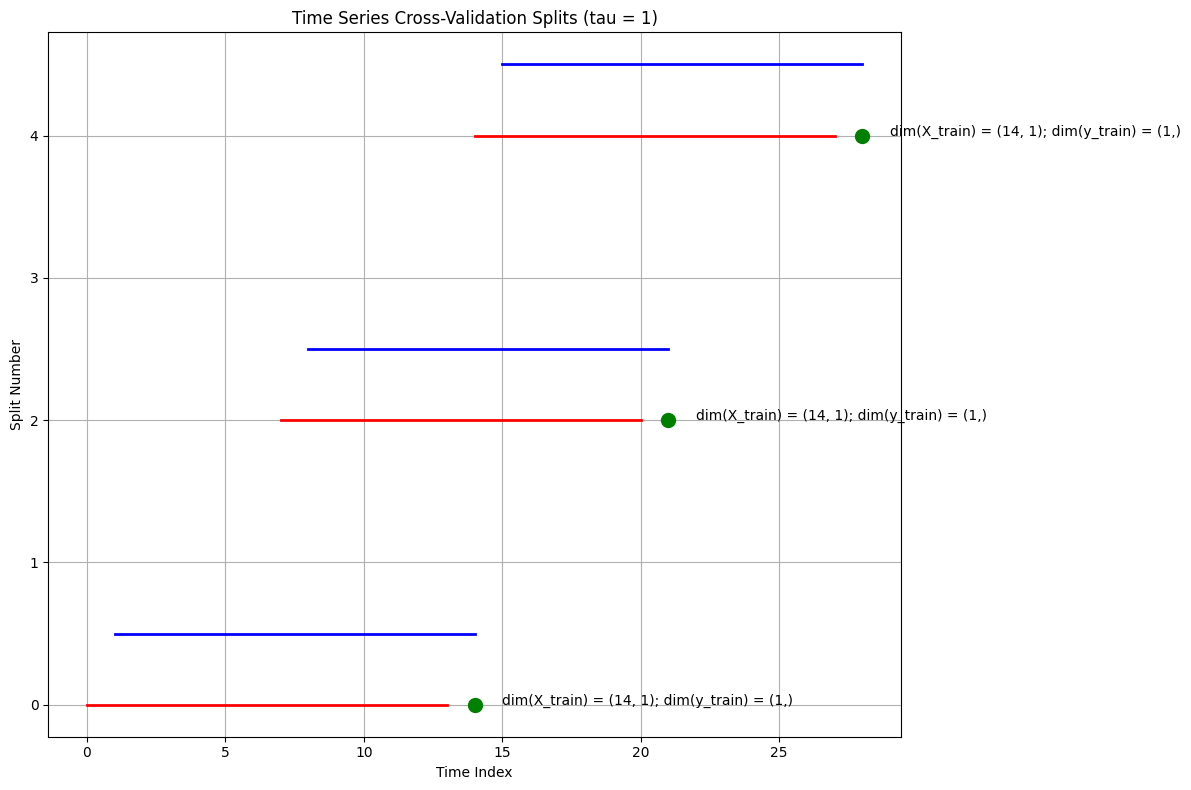

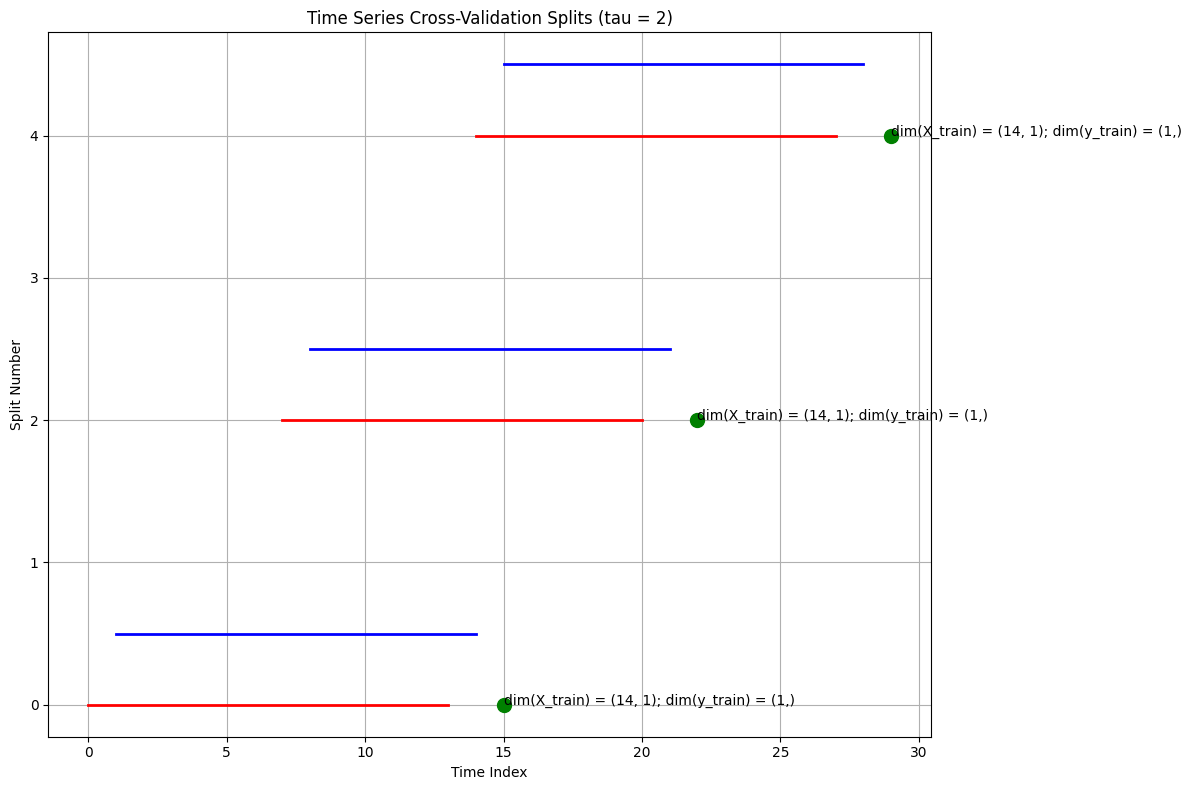

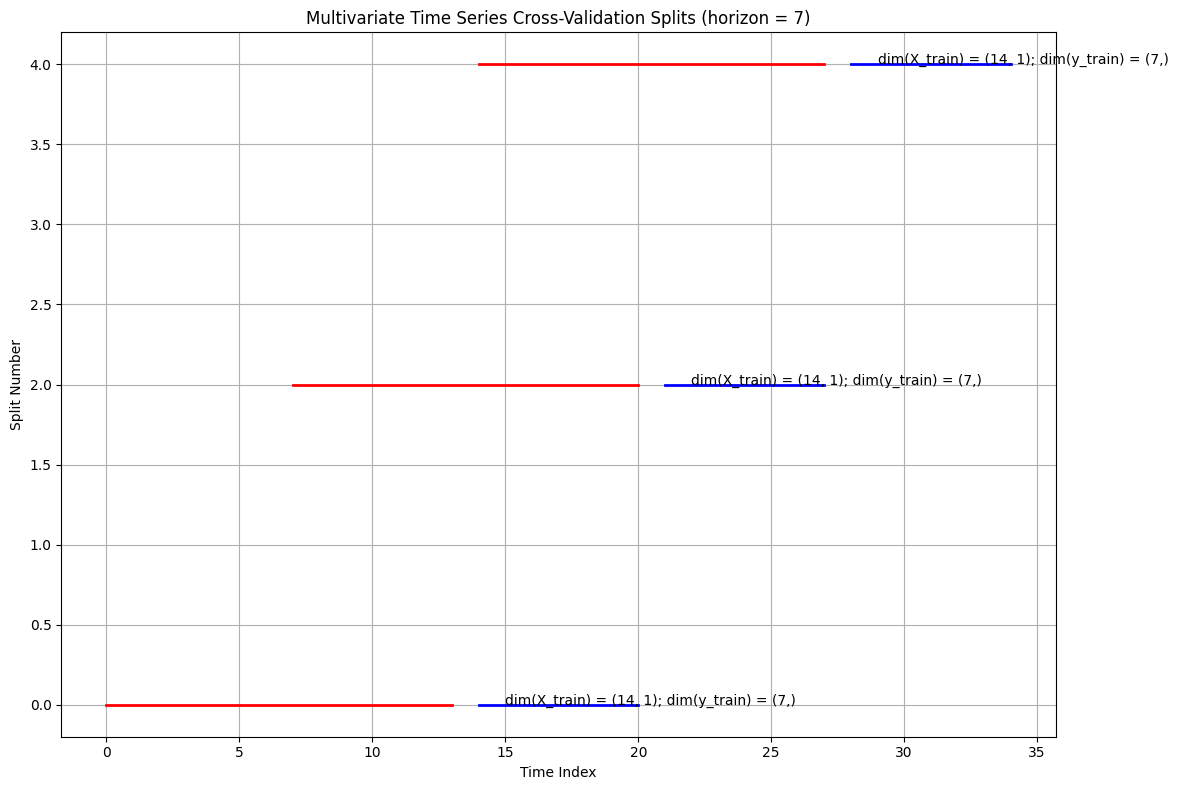

In [ ]:
# First, load the data as per your provided code
import pandas as pd

data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Sort by date (index) in ascending order
df.sort_index(inplace=True)

def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Return Calculation
df["Return"] = df["Price"].pct_change()

# Replace the first NaN in Return with 0
df["Return"].iloc[0] = 0

# Cumulative Return Calculation
df["Cumulative_Return"] = df["Return"].cumsum()

# Volatility Calculation in Rolling Windows
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

# Now visualize the cross-validation splits
# Example for univariate prediction with tau=1
fig1 = plot_time_series_cv(df, 'Price', input_window=14, forecast_horizon=7, tau=1, n_splits=3)
fig1.savefig('cv_splits_tau1.png')

# Example for univariate prediction with tau=2
fig2 = plot_time_series_cv(df, 'Price', input_window=14, forecast_horizon=7, tau=2, n_splits=3)
fig2.savefig('cv_splits_tau2.png')

# Example for multivariate prediction (full horizon)
fig3 = plot_multivariate_time_series_cv(df, 'Price', input_window=14, forecast_horizon=7, n_splits=3)
fig3.savefig('cv_splits_multivariate.png')

# Create datasets for univariate prediction
univariate_data_tau1 = create_univariate_prediction_datasets(
    df, 'Price', 'Price', input_window=14, forecast_horizon=7, tau=1
)

print("Univariate datasets (tau=1) shapes:")
print("X_train shape:", univariate_data_tau1['X_train'].shape)
print("y_train shape:", univariate_data_tau1['y_train'].shape)
print("X_val shape:", univariate_data_tau1['X_val'].shape)
print("y_val shape:", univariate_data_tau1['y_val'].shape)
print("X_test shape:", univariate_data_tau1['X_test'].shape)
print("y_test shape:", univariate_data_tau1['y_test'].shape)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load and prepare the data
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Sort by date in ascending order
df.sort_index(inplace=True)

# Function to convert volume to number
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

# Apply cleanup function
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Return calculation (Return)
df["Return"] = df["Price"].pct_change().fillna(0)

# CumulativeReturn Calculation
df["Cumulative_Return"] = df["Return"].cumsum()

# Volatility Calculation in Rolling Windows
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

# Define a function to create time series data
def create_dataset(dataset, look_back, predict_forward):
    """
    Convert a time series to a dataset suitable for supervised learning.
    
    Args:
        dataset: Series or array containing the time series data
        look_back: Number of lag observations as input (X)
        predict_forward: Number of observations to predict (Y)
        
    Returns:
        X, y arrays for model training/testing
    """
    X, y = [], []
    for i in range(len(dataset) - look_back - predict_forward + 1):
        X.append(dataset[i:(i + look_back)])
        y.append(dataset[i + look_back:i + look_back + predict_forward])
    return np.array(X), np.array(y)

# Define metrics calculation function
def calculate_metrics(y_true, y_pred):
    """Calculate all required metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    # Calculate MAPE, handling zeros in y_true
    mask = y_true != 0
    if np.any(mask):
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

# Function to calculate statistical tests on residuals
# Function to calculate statistical tests on residuals
def calculate_tests(residuals):
    """Calculate statistical tests for residuals."""
    # Ljung-Box test for autocorrelation
    lb_test = acorr_ljungbox(residuals, lags=10)
    lb_pvalue = lb_test.iloc[0, 1]  # p-value of lag 1
    
    # Jarque-Bera test for normality
    jb_stat, jb_pvalue = stats.jarque_bera(residuals)
    
    # Alternative to BDS test - use Durbin-Watson statistic
    # The D-W test checks for autocorrelation in residuals
    # Values near 2 indicate no autocorrelation
    from statsmodels.stats.stattools import durbin_watson
    try:
        dw_stat = durbin_watson(residuals)
        # Convert to a pseudo p-value (this is a simplification)
        # DW stat ranges from 0-4, with 2 being ideal
        # Convert this to a "p-value" between 0-1
        # where values closer to 1 suggest randomness
        bds_pvalue = 1 - abs(dw_stat - 2) / 2
    except:
        # Fallback if Durbin-Watson test fails
        bds_pvalue = np.nan
    
    return {
        'Ljung-Box (p-value)': lb_pvalue,
        'Jarque-Bera (p-value)': jb_pvalue,
        'BDS (p-value)': bds_pvalue
    }

# Function to plot residual analysis
def plot_residual_analysis(residuals, title_prefix):
    """Create plots for residual analysis."""
    fig, axes = plt.subplots(3, 1, figsize=(12, 12))
    
    # Residual Series Plot
    axes[0].plot(residuals)
    axes[0].set_title(f'{title_prefix} - Residual Series')
    axes[0].set_xlabel('Index')
    axes[0].set_ylabel('Residual')
    
    # Q-Q Plot
    sm.qqplot(np.array(residuals), line='45', ax=axes[1])
    axes[1].set_title(f'{title_prefix} - QQ Plot')
    
    # ACF Plot
    sm.graphics.tsa.plot_acf(residuals, lags=20, ax=axes[2])
    axes[2].set_title(f'{title_prefix} - ACF of Residuals')
    
    plt.tight_layout()
    return fig

# Define model building functions
def build_mlp_model(input_shape, output_shape):
    """Build a Multilayer Perceptron model."""
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_shape,)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(output_shape)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_rnn_model(input_shape, output_shape):
    """Build a Recurrent Neural Network model."""
    model = Sequential([
        SimpleRNN(64, input_shape=(input_shape, 1), return_sequences=True),
        Dropout(0.2),
        SimpleRNN(32),
        Dropout(0.2),
        Dense(output_shape)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm_model(input_shape, output_shape):
    """Build an LSTM model."""
    model = Sequential([
        LSTM(64, input_shape=(input_shape, 1), return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(output_shape)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Main evaluation function
def evaluate_models():
    # Target variable to predict
    target_col = 'Price'
    target_data = df[target_col].values.reshape(-1, 1)
    
    # Scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(target_data)
    
    # Define the window sizes to test
    window_sizes = [7, 14, 21, 28]  # Look-back periods
    forecast_periods = [7, 14, 21, 28]  # Validation/test lengths
    
    # Define model types
    model_types = {
        'MLP': build_mlp_model,
        'RNN': build_rnn_model,
        'LSTM': build_lstm_model
    }
    
    # Store results
    training_results = []
    test_results = []
    
    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    # Loop through all combinations
    for look_back in window_sizes:
        for predict_forward in forecast_periods:
            # Create datasets
            X, y = create_dataset(scaled_data, look_back, predict_forward)
            
            # Total sample size
            n_samples = len(X)
            
            # Ensure we have enough data
            if n_samples < 50:  # Arbitrary minimum sample size
                print(f"Skipping look_back={look_back}, predict_forward={predict_forward} due to insufficient data")
                continue
                
            # Split indices for training, validation, and test
            test_size = predict_forward
            val_size = predict_forward
            train_size = n_samples - test_size - val_size
            
            train_indices = range(0, train_size)
            val_indices = range(train_size, train_size + val_size)
            test_indices = range(train_size + val_size, n_samples)
            
            # Create train, validation, test sets
            X_train, y_train = X[train_indices], y[train_indices]
            X_val, y_val = X[val_indices], y[val_indices]
            X_test, y_test = X[test_indices], y[test_indices]
            
            # Reshape for RNN/LSTM models if needed
            X_train_rnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
            X_val_rnn = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
            X_test_rnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
            
            # For each model type
            for model_name, model_builder in model_types.items():
                print(f"Training {model_name} with look_back={look_back}, predict_forward={predict_forward}")
                
                # Build and train the model
                if model_name == 'MLP':
                    model = model_builder(look_back, predict_forward)
                    # Flatten y arrays for MLP
                    y_train_flat = y_train.reshape(y_train.shape[0], -1)
                    y_val_flat = y_val.reshape(y_val.shape[0], -1)
                    y_test_flat = y_test.reshape(y_test.shape[0], -1)
                    
                    # Train the model
                    history = model.fit(
                        X_train, y_train_flat,
                        epochs=100,
                        batch_size=32,
                        validation_data=(X_val, y_val_flat),
                        callbacks=[early_stopping],
                        verbose=0
                    )
                    
                    # Make predictions
                    train_pred = model.predict(X_train)
                    val_pred = model.predict(X_val)
                    test_pred = model.predict(X_test)
                    
                    # Reshape back for evaluation
                    train_pred = train_pred.reshape(train_pred.shape[0], predict_forward, 1)
                    val_pred = val_pred.reshape(val_pred.shape[0], predict_forward, 1)
                    test_pred = test_pred.reshape(test_pred.shape[0], predict_forward, 1)
                    
                else:  # RNN or LSTM
                    model = model_builder(look_back, predict_forward)
                    
                    # Train the model
                    history = model.fit(
                        X_train_rnn, y_train,
                        epochs=100,
                        batch_size=32,
                        validation_data=(X_val_rnn, y_val),
                        callbacks=[early_stopping],
                        verbose=0
                    )
                    
                    # Make predictions
                    train_pred = model.predict(X_train_rnn)
                    val_pred = model.predict(X_val_rnn)
                    test_pred = model.predict(X_test_rnn)
                
                # Inverse transform predictions and actual values
                train_pred_inv = scaler.inverse_transform(train_pred.reshape(-1, 1))
                train_pred_inv = train_pred_inv.reshape(train_pred.shape[0], train_pred.shape[1])

                val_pred_inv = scaler.inverse_transform(val_pred.reshape(-1, 1))
                val_pred_inv = val_pred_inv.reshape(val_pred.shape[0], val_pred.shape[1])

                test_pred_inv = scaler.inverse_transform(test_pred.reshape(-1, 1))
                test_pred_inv = test_pred_inv.reshape(test_pred.shape[0], test_pred.shape[1])

                # Also reshape y data to match
                y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
                y_train_inv = y_train_inv.reshape(y_train.shape[0], y_train.shape[1])

                y_val_inv = scaler.inverse_transform(y_val.reshape(-1, 1))
                y_val_inv = y_val_inv.reshape(y_val.shape[0], y_val.shape[1])

                y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
                y_test_inv = y_test_inv.reshape(y_test.shape[0], y_test.shape[1])

                # Calculate residuals - now the shapes should match
                train_residuals = (y_train_inv - train_pred_inv).flatten()
                val_residuals = (y_val_inv - val_pred_inv).flatten()
                test_residuals = (y_test_inv - test_pred_inv).flatten()
                
                # Calculate metrics
                train_metrics = calculate_metrics(y_train_inv.flatten(), train_pred_inv.flatten())
                val_metrics = calculate_metrics(y_val_inv.flatten(), val_pred_inv.flatten())
                test_metrics = calculate_metrics(y_test_inv.flatten(), test_pred_inv.flatten())

                # Calculate statistical tests
                train_tests = calculate_tests(train_residuals)
                val_tests = calculate_tests(val_residuals)
                test_tests = calculate_tests(test_residuals)
                
                # Create residual analysis plots
                train_plot = plot_residual_analysis(
                    train_residuals, 
                    f"{model_name} (Train) - Window {look_back} - Forecast {predict_forward}"
                )
                val_plot = plot_residual_analysis(
                    val_residuals, 
                    f"{model_name} (Validation) - Window {look_back} - Forecast {predict_forward}"
                )
                test_plot = plot_residual_analysis(
                    test_residuals, 
                    f"{model_name} (Test) - Window {look_back} - Forecast {predict_forward}"
                )
                
                # Save training results
                training_result = {
                    'Model': model_name,
                    'Look Back': look_back,
                    'Forecast Period': predict_forward,
                    'Set': 'Training',
                    'MAE': train_metrics['MAE'],
                    'MSE': train_metrics['MSE'],
                    'RMSE': train_metrics['RMSE'],
                    'MAPE': train_metrics['MAPE'],
                    'R2': train_metrics['R2'],
                    'Ljung-Box (p-value)': train_tests['Ljung-Box (p-value)'],
                    'BDS (p-value)': train_tests['BDS (p-value)'],
                    'Jarque-Bera (p-value)': train_tests['Jarque-Bera (p-value)']
                }
                training_results.append(training_result)
                
                # Save validation results
                val_result = {
                    'Model': model_name,
                    'Look Back': look_back,
                    'Forecast Period': predict_forward,
                    'Set': 'Validation',
                    'MAE': val_metrics['MAE'],
                    'MSE': val_metrics['MSE'],
                    'RMSE': val_metrics['RMSE'],
                    'MAPE': val_metrics['MAPE'],
                    'R2': val_metrics['R2'],
                    'Ljung-Box (p-value)': val_tests['Ljung-Box (p-value)'],
                    'BDS (p-value)': val_tests['BDS (p-value)'],
                    'Jarque-Bera (p-value)': val_tests['Jarque-Bera (p-value)']
                }
                training_results.append(val_result)
                
                # Save test results
                test_result = {
                    'Model': model_name,
                    'Look Back': look_back,
                    'Forecast Period': predict_forward,
                    'Set': 'Test',
                    'MAE': test_metrics['MAE'],
                    'MSE': test_metrics['MSE'],
                    'RMSE': test_metrics['RMSE'],
                    'MAPE': test_metrics['MAPE'],
                    'R2': test_metrics['R2'],
                    'Ljung-Box (p-value)': test_tests['Ljung-Box (p-value)'],
                    'BDS (p-value)': test_tests['BDS (p-value)']
                }
                test_results.append(test_result)
                
                # Close the figures to free memory
                plt.close(train_plot)
                plt.close(val_plot)
                plt.close(test_plot)
    
    # Create DataFrames from results
    train_df = pd.DataFrame(training_results)
    test_df = pd.DataFrame(test_results)
    
    return train_df, test_df

# Function to create summary tables as required in the exercise
def create_summary_tables(train_df, test_df):
    """Create summary tables as specified in the exercise."""
    # Table for training/validation sets (point 4 in the exercise)
    residual_table = train_df.copy()
    
    # Table for test sets (point 5 in the exercise)
    prediction_table = test_df.copy()
    
    # Return both tables
    return residual_table, prediction_table

# Function to visualize results
def visualize_results(train_df, test_df):
    """Create visualizations to compare model performance."""
    # Filter for test set only
    test_only = test_df.copy()
    
    # Create figures for different metrics
    metrics = ['MAPE', 'MAE', 'RMSE', 'R2']
    
    for metric in metrics:
        plt.figure(figsize=(12, 8))
        
        # Create a grouped bar chart
        pivot_table = test_only.pivot_table(
            values=metric,
            index=['Look Back'],
            columns=['Model', 'Forecast Period']
        )
        
        pivot_table.plot(kind='bar')
        plt.title(f'{metric} Comparison Across Models')
        plt.xlabel('Look Back Window')
        plt.ylabel(metric)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.legend(title='Model, Forecast Period')
        plt.savefig(f'{metric}_comparison.png')
        plt.close()
    
    # Create a heatmap of RMSE values
    plt.figure(figsize=(14, 10))
    heatmap_data = test_only.pivot_table(
        values='RMSE',
        index=['Model', 'Look Back'],
        columns=['Forecast Period']
    )
    
    sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='.2f')
    plt.title('RMSE Values Across Different Models and Parameters')
    plt.tight_layout()
    plt.savefig('rmse_heatmap.png')
    plt.close()

# Main function to run the entire analysis
def main():
    """Run the entire analysis pipeline."""
    print("Starting Time Series Analysis...")
    
    # Train and evaluate models
    train_results, test_results = evaluate_models()
    
    # Create summary tables
    residual_table, prediction_table = create_summary_tables(train_results, test_results)
    
    # Save tables to CSV
    residual_table.to_csv('residual_results.csv', index=False)
    prediction_table.to_csv('prediction_results.csv', index=False)
    
    # Visualize results
    visualize_results(train_results, test_results)
    
    print("Analysis complete!")
    
    return residual_table, prediction_table

# Run the analysis
if __name__ == "__main__":
    residual_table, prediction_table = main()
    
    # Display summary tables
    print("\nResidual (Training/Validation) Summary Table:")
    print(residual_table)
    
    print("\nPrediction (Test) Summary Table:")
    print(prediction_table)

Starting Time Series Analysis...
Training MLP with look_back=7, predict_forward=7
1/1 [==============================] - 0s 14ms/step
Training RNN with look_back=7, predict_forward=7
1/1 [==============================] - 0s 14ms/step
Training LSTM with look_back=7, predict_forward=7
1/1 [==============================] - 0s 17ms/step
Training MLP with look_back=7, predict_forward=14
1/1 [==============================] - 0s 14ms/step
Training RNN with look_back=7, predict_forward=14
1/1 [==============================] - 0s 16ms/step
Training LSTM with look_back=7, predict_forward=14
1/1 [==============================] - 0s 19ms/step
Training MLP with look_back=7, predict_forward=21
1/1 [==============================] - 0s 15ms/step
Training RNN with look_back=7, predict_forward=21
1/1 [==============================] - 0s 16ms/step
Training LSTM with look_back=7, predict_forward=21
1/1 [==============================] - 0s 18ms/step
Training MLP with look_back=7, predict_forward=28

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

Starting Enhanced Bitcoin Price Analysis Pipeline...
Loading and preparing data...
Data preparation complete. DataFrame shape: (4999, 12)

First few rows of the prepared data:
            Price  Open  High  Low    Vol.  Change %  Return  \
Date                                                           
2010-07-18    0.1   0.0   0.1  0.1    80.0       0.0     0.0   
2010-07-19    0.1   0.1   0.1  0.1   570.0       0.0     0.0   
2010-07-20    0.1   0.1   0.1  0.1   260.0       0.0     0.0   
2010-07-21    0.1   0.1   0.1  0.1   580.0       0.0     0.0   
2010-07-22    0.1   0.1   0.1  0.1  2160.0       0.0     0.0   

            Cumulative_Return  Volatility_7d  Volatility_14d  Volatility_21d  \
Date                                                                           
2010-07-18                0.0            NaN             NaN             NaN   
2010-07-19                0.0            0.0             0.0             0.0   
2010-07-20                0.0            0.0           

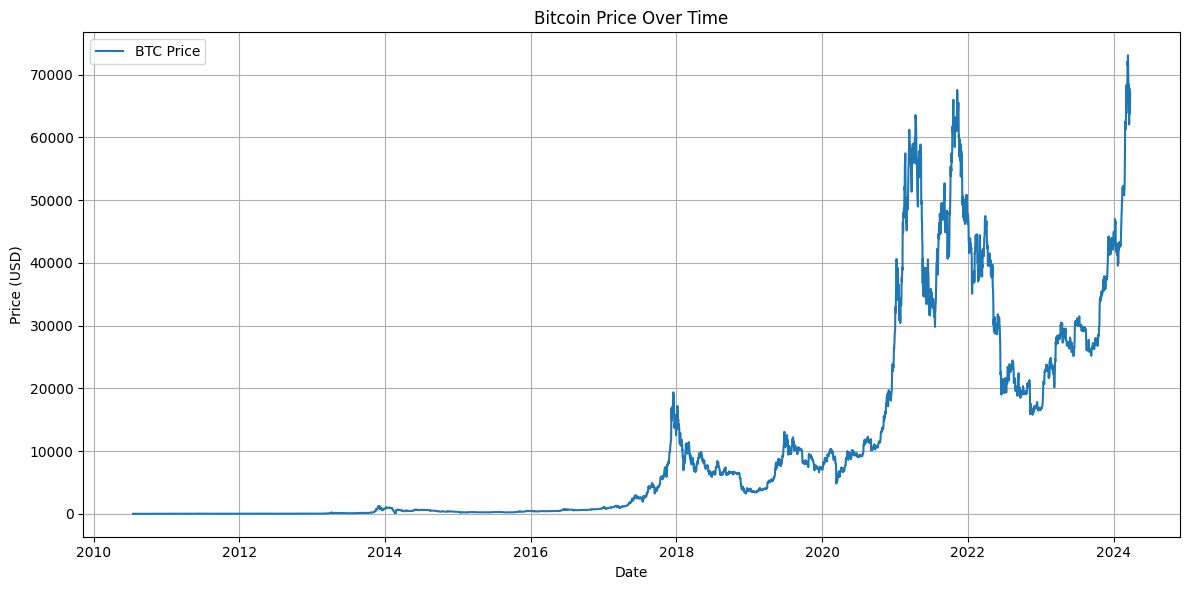


===== Starting Model Evaluation =====

==== Testing look_back=7, predict_forward=7 ====

--- Training MLP (1/24) ---
Epoch 1/50
156/156 [==============================] - 2s 6ms/step - loss: 0.0124 - val_loss: 0.0264
Epoch 2/50
156/156 [==============================] - 1s 4ms/step - loss: 0.0046 - val_loss: 0.0072
Epoch 3/50
156/156 [==============================] - 1s 4ms/step - loss: 0.0034 - val_loss: 0.0222
Epoch 4/50
156/156 [==============================] - 1s 4ms/step - loss: 0.0031 - val_loss: 0.0139
Epoch 5/50
156/156 [==============================] - 1s 4ms/step - loss: 0.0027 - val_loss: 0.0130
Epoch 6/50
156/156 [==============================] - 1s 5ms/step - loss: 0.0024 - val_loss: 0.0174
Epoch 7/50
156/156 [==============================] - 1s 4ms/step - loss: 0.0023 - val_loss: 0.0086
Epoch 8/50
156/156 [==============================] - 1s 4ms/step - loss: 0.0022 - val_loss: 0.0083
Epoch 9/50
156/156 [==============================] - 1s 4ms/step - loss: 0.0022 -

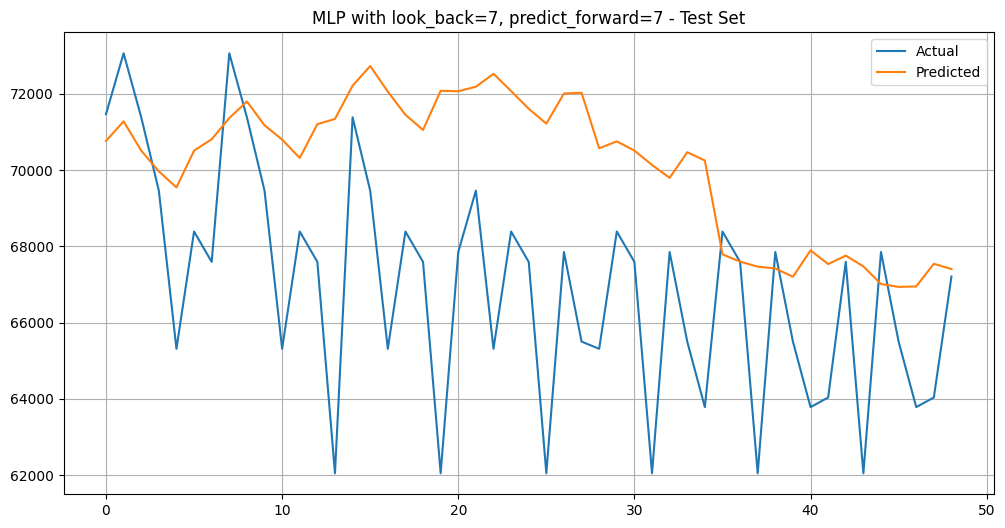


--- Training RNN (2/24) ---
Epoch 1/50
156/156 [==============================] - 3s 9ms/step - loss: 0.0127 - val_loss: 0.0479
Epoch 2/50
156/156 [==============================] - 2s 12ms/step - loss: 0.0046 - val_loss: 0.0267
Epoch 3/50
156/156 [==============================] - 2s 11ms/step - loss: 0.0035 - val_loss: 0.0250
Epoch 4/50
156/156 [==============================] - 2s 11ms/step - loss: 0.0026 - val_loss: 0.0115
Epoch 5/50
156/156 [==============================] - 2s 11ms/step - loss: 0.0022 - val_loss: 0.0244
Epoch 6/50
156/156 [==============================] - 1s 8ms/step - loss: 0.0020 - val_loss: 0.0112
Epoch 7/50
156/156 [==============================] - 1s 7ms/step - loss: 0.0018 - val_loss: 0.0123
Epoch 8/50
156/156 [==============================] - 1s 7ms/step - loss: 0.0017 - val_loss: 0.0098
Epoch 9/50
156/156 [==============================] - 1s 7ms/step - loss: 0.0015 - val_loss: 0.0114
Epoch 10/50
156/156 [==============================] - 1s 7ms/step 

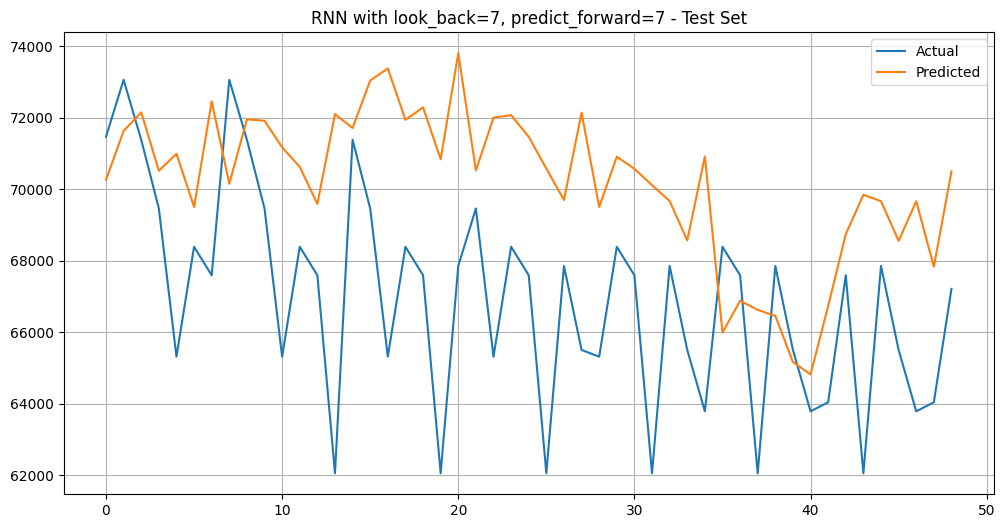


Test Set Residual Analysis:


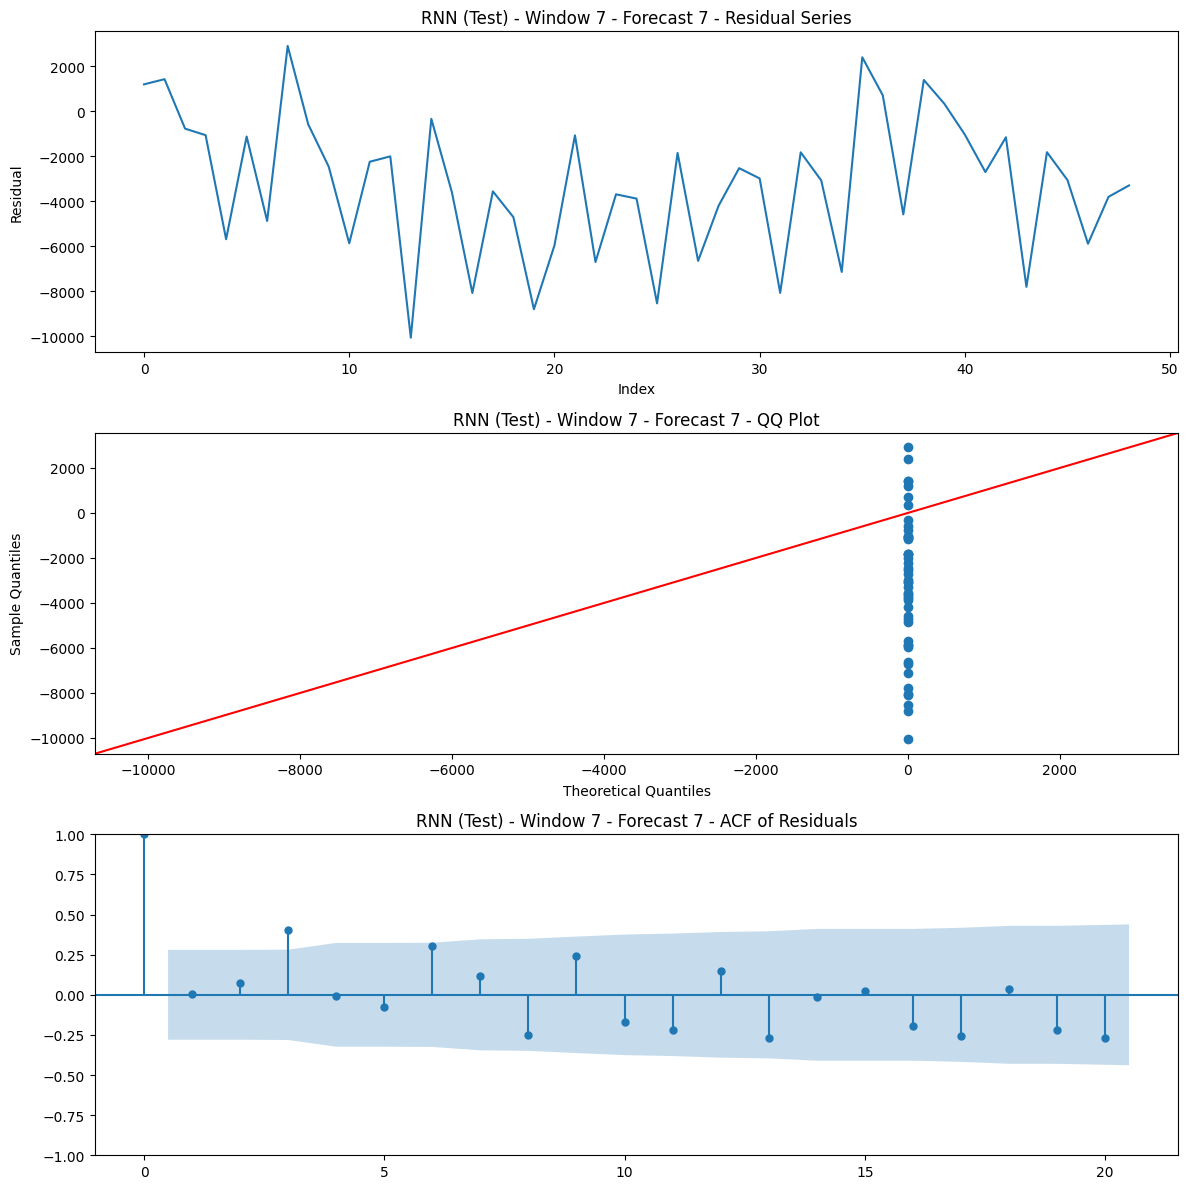


Current Model Comparison (sorted by Test RMSE):
  Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
0   MLP          7                7  4287.020486  3453.347162 -1.186213
1   RNN          7                7  4462.163558  3658.052742 -1.368494

--- Training LSTM (3/24) ---
Epoch 1/50
156/156 [==============================] - 5s 17ms/step - loss: 0.0094 - val_loss: 0.0143
Epoch 2/50
156/156 [==============================] - 3s 22ms/step - loss: 0.0022 - val_loss: 0.0130
Epoch 3/50
156/156 [==============================] - 2s 11ms/step - loss: 0.0019 - val_loss: 0.0208
Epoch 4/50
156/156 [==============================] - 2s 11ms/step - loss: 0.0017 - val_loss: 0.0030
Epoch 5/50
156/156 [==============================] - 2s 11ms/step - loss: 0.0015 - val_loss: 0.0186
Epoch 6/50
156/156 [==============================] - 2s 11ms/step - loss: 0.0014 - val_loss: 0.0089
Epoch 7/50
156/156 [==============================] - 2s 11ms/step - loss: 0.0014 - val_loss: 0.013

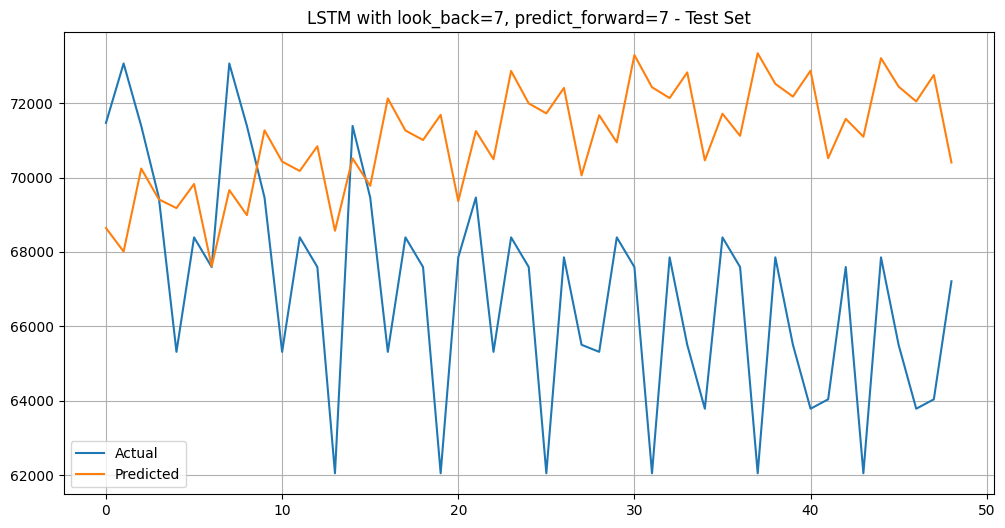


Current Model Comparison (sorted by Test RMSE):
  Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
0   MLP          7                7  4287.020486  3453.347162 -1.186213
1   RNN          7                7  4462.163558  3658.052742 -1.368494
2  LSTM          7                7  5525.594889  4745.705899 -2.631947


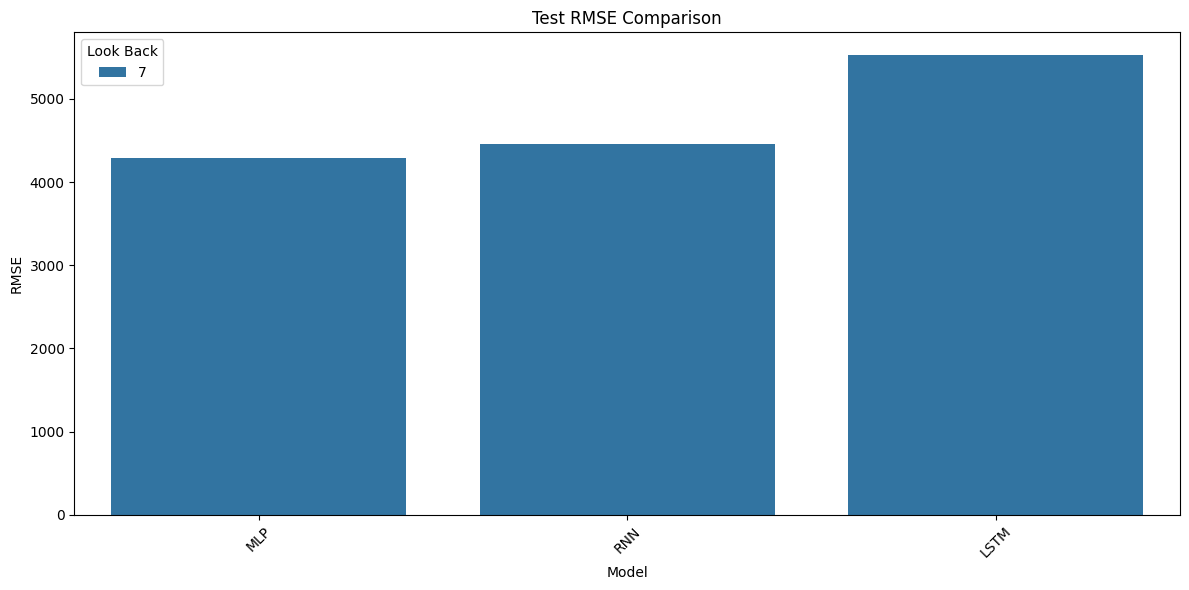


==== Testing look_back=7, predict_forward=14 ====

--- Training MLP (4/24) ---
Epoch 1/50
155/155 [==============================] - 1s 2ms/step - loss: 0.0179 - val_loss: 0.0237
Epoch 2/50
155/155 [==============================] - 0s 2ms/step - loss: 0.0051 - val_loss: 0.0246
Epoch 3/50
155/155 [==============================] - 0s 2ms/step - loss: 0.0038 - val_loss: 0.0217
Epoch 4/50
155/155 [==============================] - 0s 2ms/step - loss: 0.0031 - val_loss: 0.0201
Epoch 5/50
155/155 [==============================] - 0s 2ms/step - loss: 0.0029 - val_loss: 0.0220
Epoch 6/50
155/155 [==============================] - 0s 2ms/step - loss: 0.0026 - val_loss: 0.0185
Epoch 7/50
155/155 [==============================] - 0s 2ms/step - loss: 0.0025 - val_loss: 0.0140
Epoch 8/50
155/155 [==============================] - 0s 2ms/step - loss: 0.0023 - val_loss: 0.0256
Epoch 9/50
155/155 [==============================] - 0s 2ms/step - loss: 0.0023 - val_loss: 0.0178
Epoch 10/50
155/155 

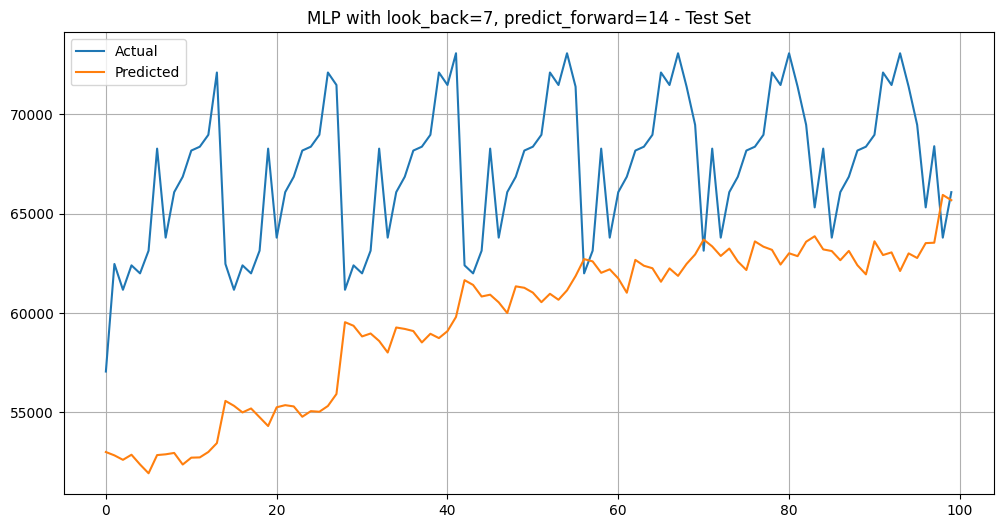


Test Set Residual Analysis:


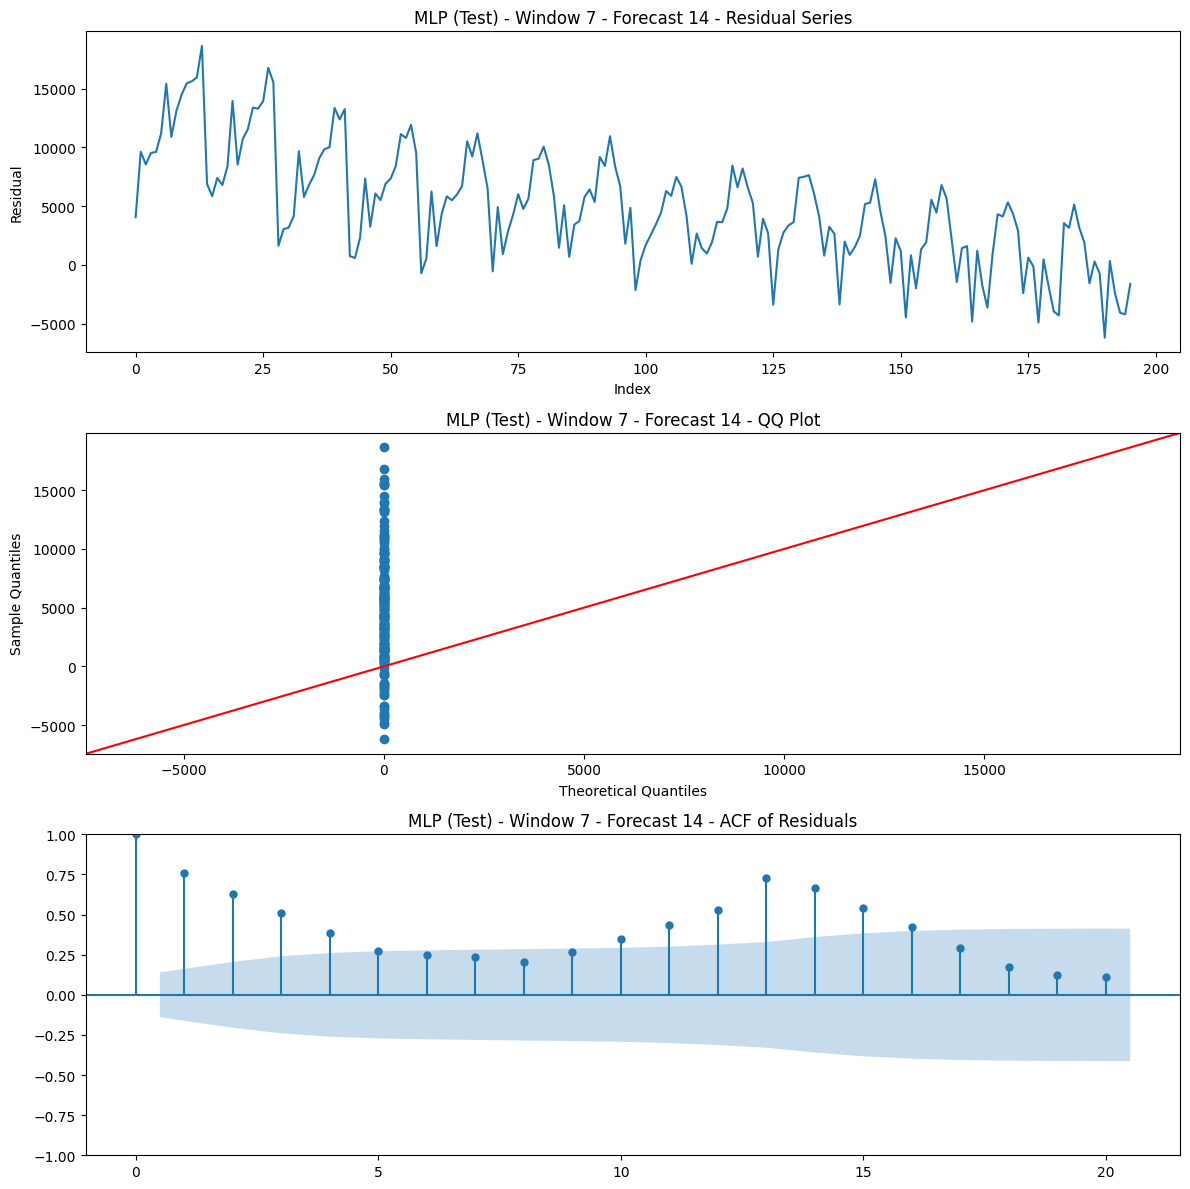


Current Model Comparison (sorted by Test RMSE):
  Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
0   MLP          7                7  4287.020486  3453.347162 -1.186213
1   RNN          7                7  4462.163558  3658.052742 -1.368494
2  LSTM          7                7  5525.594889  4745.705899 -2.631947
3   MLP          7               14  6882.823250  5590.008901 -3.221258

--- Training RNN (5/24) ---
Epoch 1/50
155/155 [==============================] - 2s 7ms/step - loss: 0.0139 - val_loss: 0.0309
Epoch 2/50
155/155 [==============================] - 1s 6ms/step - loss: 0.0049 - val_loss: 0.0245
Epoch 3/50
155/155 [==============================] - 1s 5ms/step - loss: 0.0036 - val_loss: 0.0211
Epoch 4/50
155/155 [==============================] - 1s 5ms/step - loss: 0.0029 - val_loss: 0.0206
Epoch 5/50
155/155 [==============================] - 1s 6ms/step - loss: 0.0025 - val_loss: 0.0221
Epoch 6/50
155/155 [==============================] - 1s 5ms/s

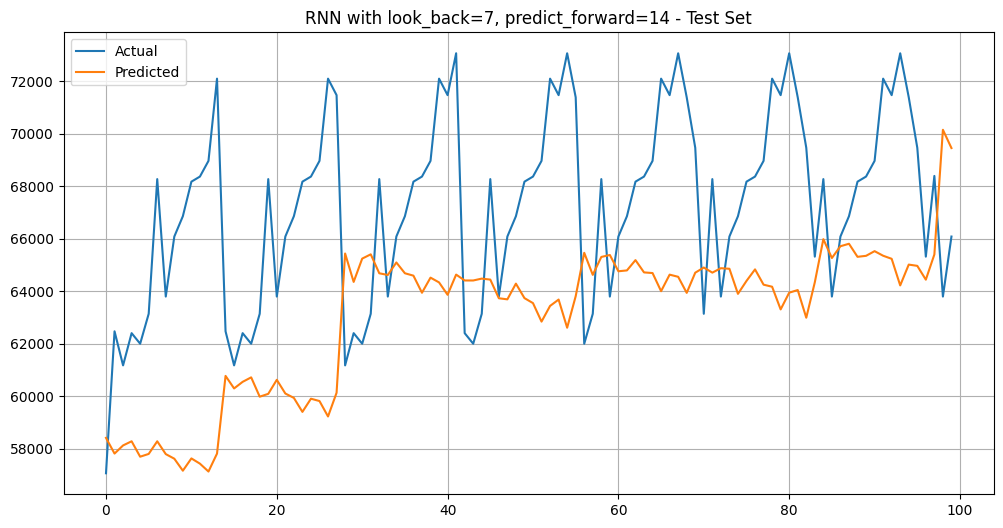


Current Model Comparison (sorted by Test RMSE):
  Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
0   MLP          7                7  4287.020486  3453.347162 -1.186213
1   RNN          7                7  4462.163558  3658.052742 -1.368494
4   RNN          7               14  4844.318344  3838.070703 -1.091096
2  LSTM          7                7  5525.594889  4745.705899 -2.631947
3   MLP          7               14  6882.823250  5590.008901 -3.221258

--- Training LSTM (6/24) ---
Epoch 1/50
155/155 [==============================] - 6s 18ms/step - loss: 0.0114 - val_loss: 0.0212
Epoch 2/50
155/155 [==============================] - 1s 8ms/step - loss: 0.0030 - val_loss: 0.0205
Epoch 3/50
155/155 [==============================] - 1s 8ms/step - loss: 0.0024 - val_loss: 0.0130
Epoch 4/50
155/155 [==============================] - 1s 8ms/step - loss: 0.0021 - val_loss: 0.0247
Epoch 5/50
155/155 [==============================] - 1s 9ms/step - loss: 0.0019 - val_l

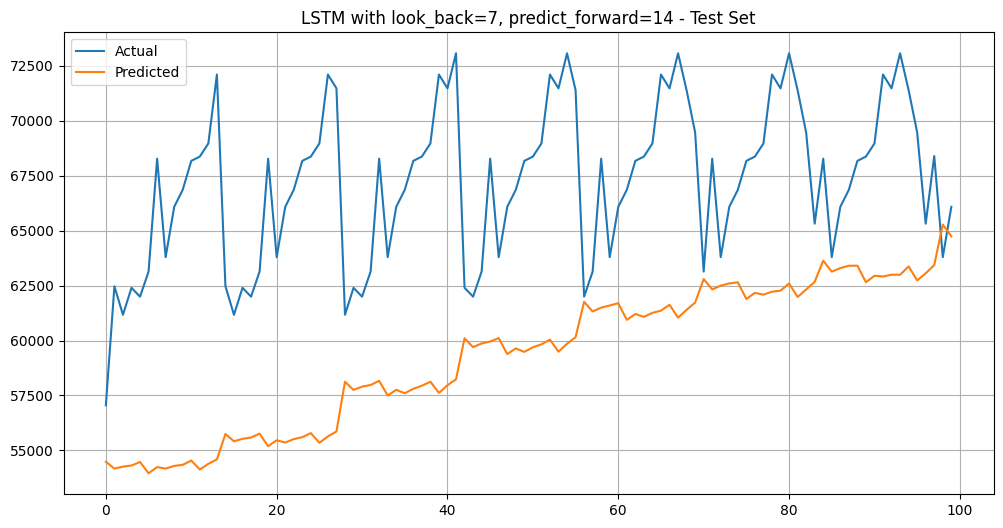


Test Set Residual Analysis:


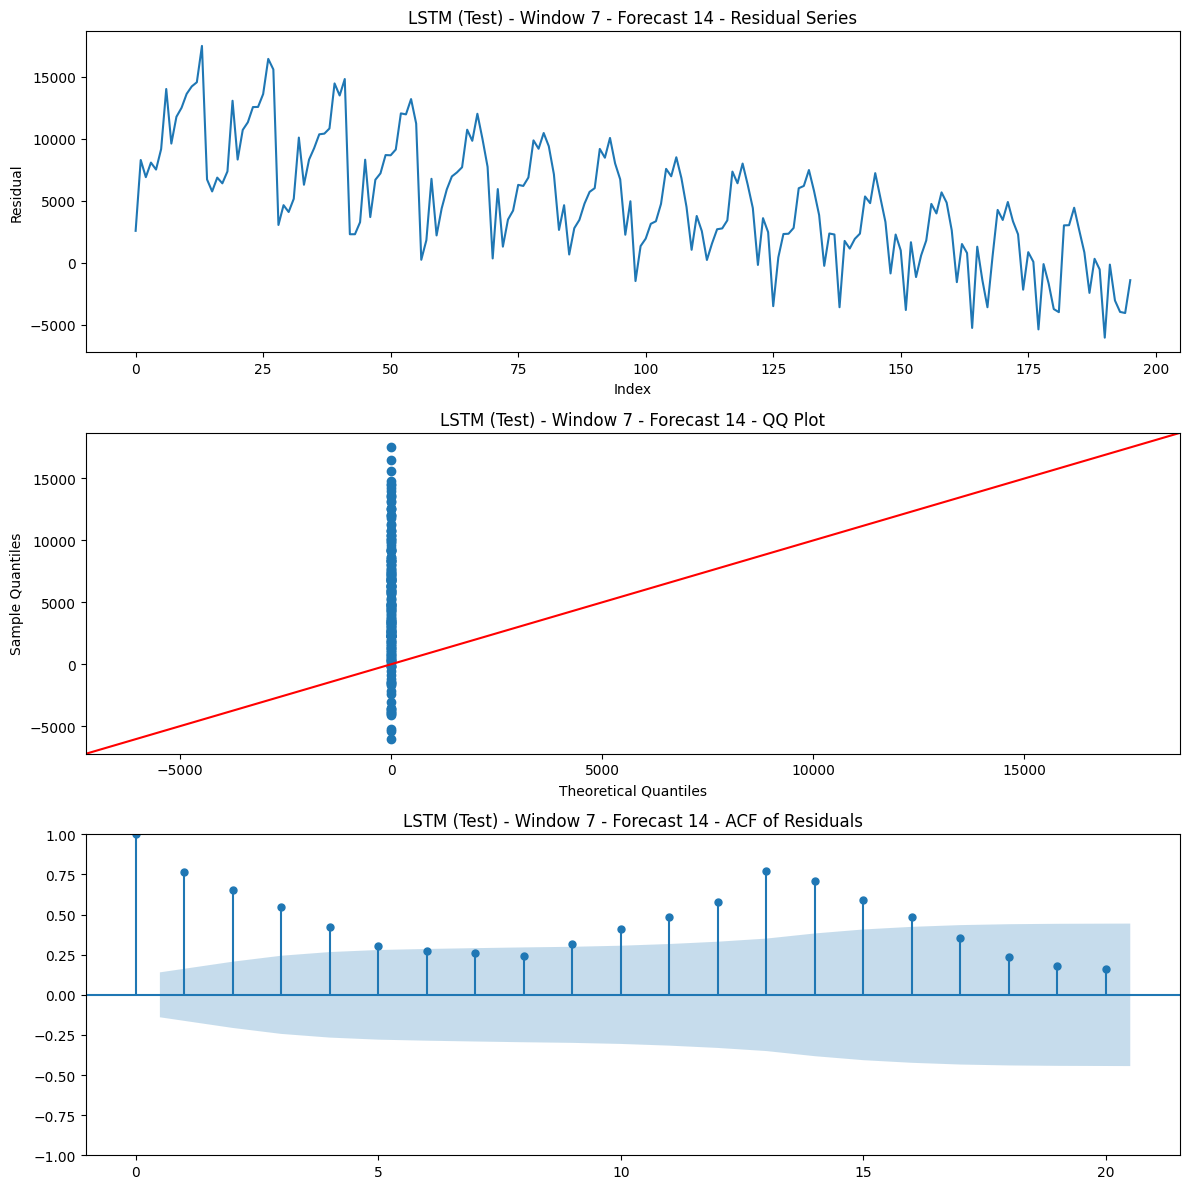


Current Model Comparison (sorted by Test RMSE):
  Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
0   MLP          7                7  4287.020486  3453.347162 -1.186213
1   RNN          7                7  4462.163558  3658.052742 -1.368494
4   RNN          7               14  4844.318344  3838.070703 -1.091096
2  LSTM          7                7  5525.594889  4745.705899 -2.631947
5  LSTM          7               14  6872.202402  5609.097648 -3.208240
3   MLP          7               14  6882.823250  5590.008901 -3.221258


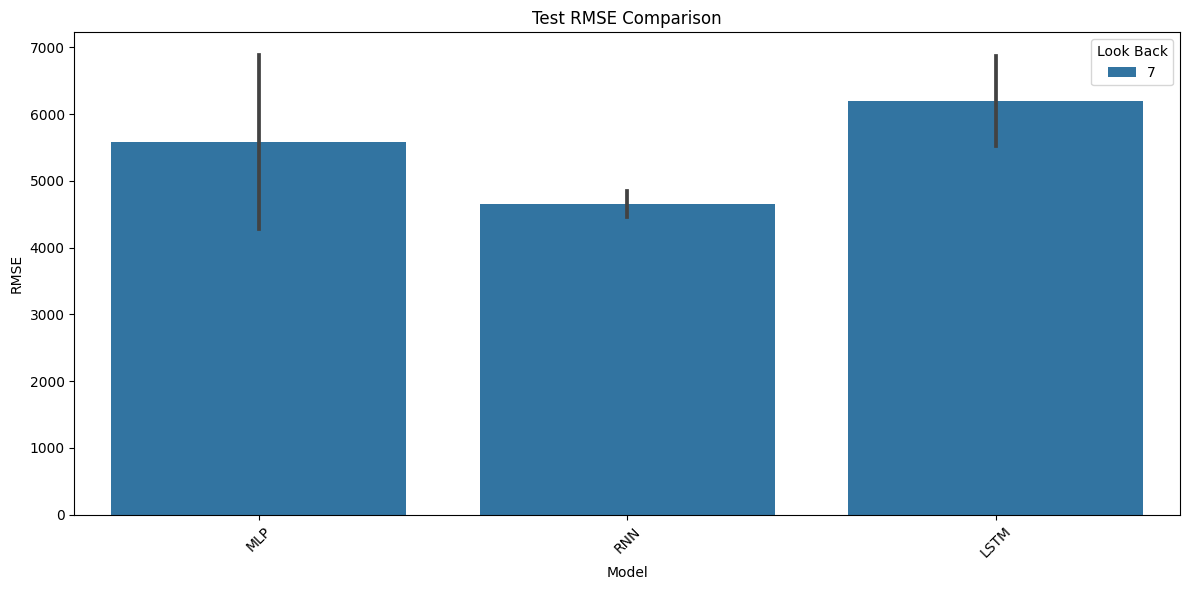


==== Testing look_back=14, predict_forward=7 ====

--- Training MLP (7/24) ---
Epoch 1/50
156/156 [==============================] - 0s 1ms/step - loss: 0.0115 - val_loss: 0.0204
Epoch 2/50
156/156 [==============================] - 0s 983us/step - loss: 0.0043 - val_loss: 0.0108
Epoch 3/50
156/156 [==============================] - 0s 1ms/step - loss: 0.0033 - val_loss: 0.0033
Epoch 4/50
156/156 [==============================] - 0s 1ms/step - loss: 0.0029 - val_loss: 0.0155
Epoch 5/50
156/156 [==============================] - 0s 1ms/step - loss: 0.0024 - val_loss: 0.0055
Epoch 6/50
156/156 [==============================] - 0s 1ms/step - loss: 0.0026 - val_loss: 0.0162
Epoch 7/50
156/156 [==============================] - 0s 991us/step - loss: 0.0023 - val_loss: 0.0050
Epoch 8/50
156/156 [==============================] - 0s 1ms/step - loss: 0.0021 - val_loss: 0.0102
Epoch 9/50
156/156 [==============================] - 0s 1ms/step - loss: 0.0022 - val_loss: 0.0055
Epoch 10/50
156/

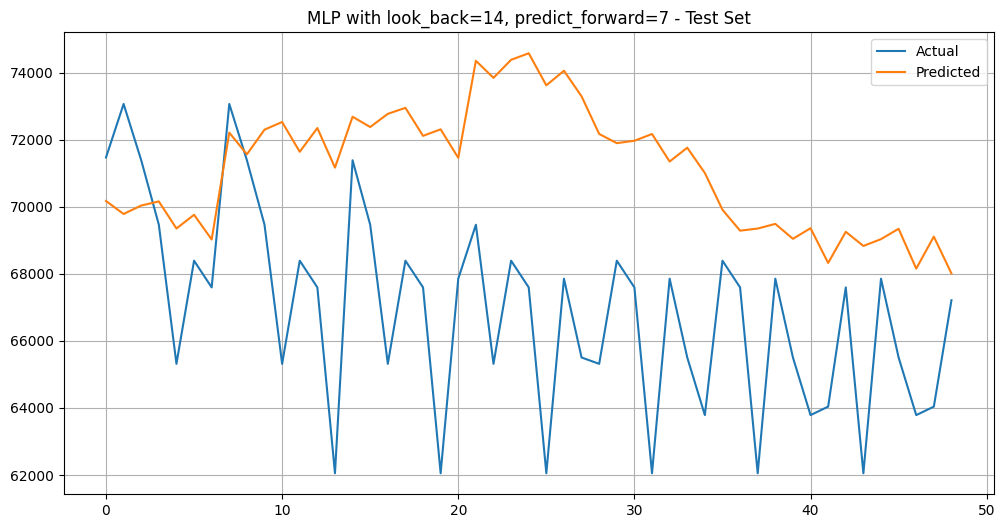


Current Model Comparison (sorted by Test RMSE):
  Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
0   MLP          7                7  4287.020486  3453.347162 -1.186213
1   RNN          7                7  4462.163558  3658.052742 -1.368494
4   RNN          7               14  4844.318344  3838.070703 -1.091096
6   MLP         14                7  5287.117321  4476.079273 -2.325211
2  LSTM          7                7  5525.594889  4745.705899 -2.631947
5  LSTM          7               14  6872.202402  5609.097648 -3.208240
3   MLP          7               14  6882.823250  5590.008901 -3.221258

--- Training RNN (8/24) ---
Epoch 1/50
156/156 [==============================] - 4s 10ms/step - loss: 0.0191 - val_loss: 0.0611
Epoch 2/50
156/156 [==============================] - 1s 9ms/step - loss: 0.0057 - val_loss: 0.0391
Epoch 3/50
156/156 [==============================] - 1s 9ms/step - loss: 0.0041 - val_loss: 0.0322
Epoch 4/50
156/156 [=========================

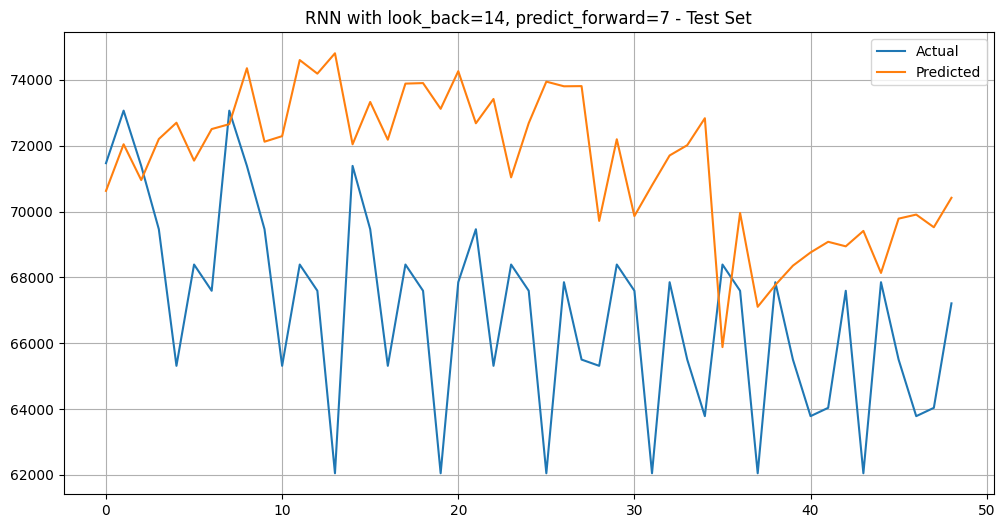


Test Set Residual Analysis:


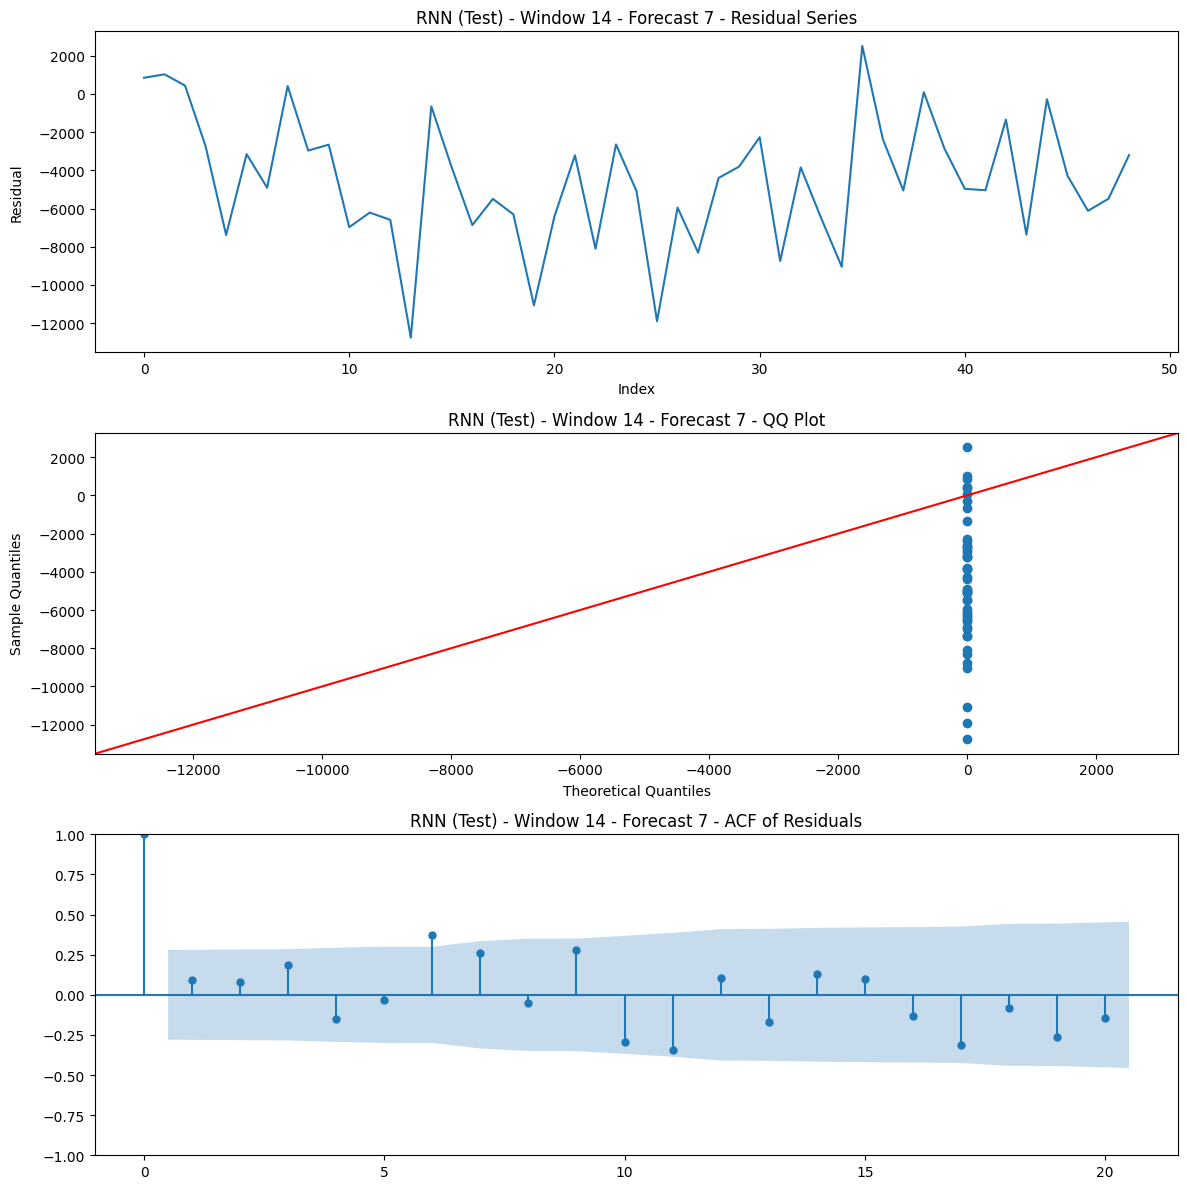


Current Model Comparison (sorted by Test RMSE):
  Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
0   MLP          7                7  4287.020486  3453.347162 -1.186213
1   RNN          7                7  4462.163558  3658.052742 -1.368494
4   RNN          7               14  4844.318344  3838.070703 -1.091096
6   MLP         14                7  5287.117321  4476.079273 -2.325211
2  LSTM          7                7  5525.594889  4745.705899 -2.631947
7   RNN         14                7  5645.567344  4787.536256 -2.791373
5  LSTM          7               14  6872.202402  5609.097648 -3.208240
3   MLP          7               14  6882.823250  5590.008901 -3.221258

--- Training LSTM (9/24) ---
Epoch 1/50
156/156 [==============================] - 5s 17ms/step - loss: 0.0073 - val_loss: 0.0468
Epoch 2/50
156/156 [==============================] - 2s 15ms/step - loss: 0.0026 - val_loss: 0.0262
Epoch 3/50
156/156 [==============================] - 2s 15ms/step - lo

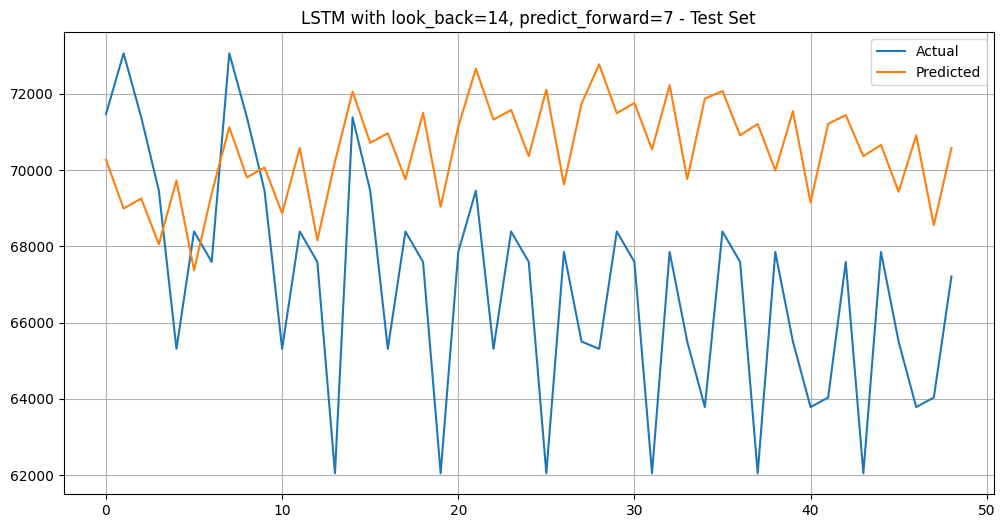


Current Model Comparison (sorted by Test RMSE):
  Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
0   MLP          7                7  4287.020486  3453.347162 -1.186213
1   RNN          7                7  4462.163558  3658.052742 -1.368494
8  LSTM         14                7  4813.947281  4118.660332 -1.756665
4   RNN          7               14  4844.318344  3838.070703 -1.091096
6   MLP         14                7  5287.117321  4476.079273 -2.325211
2  LSTM          7                7  5525.594889  4745.705899 -2.631947
7   RNN         14                7  5645.567344  4787.536256 -2.791373
5  LSTM          7               14  6872.202402  5609.097648 -3.208240
3   MLP          7               14  6882.823250  5590.008901 -3.221258


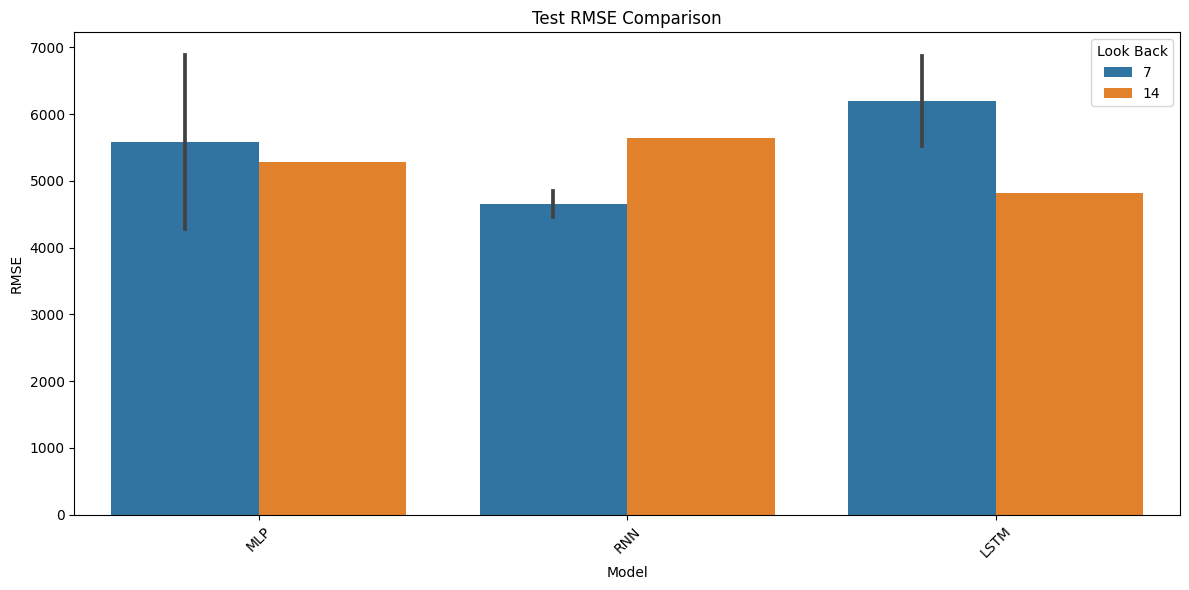


==== Testing look_back=14, predict_forward=14 ====

--- Training MLP (10/24) ---
Epoch 1/50
155/155 [==============================] - 0s 2ms/step - loss: 0.0149 - val_loss: 0.0405
Epoch 2/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0052 - val_loss: 0.0216
Epoch 3/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0035 - val_loss: 0.0176
Epoch 4/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0028 - val_loss: 0.0160
Epoch 5/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0026 - val_loss: 0.0153
Epoch 6/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0025 - val_loss: 0.0133
Epoch 7/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0024 - val_loss: 0.0164
Epoch 8/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0023 - val_loss: 0.0090
Epoch 9/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0021 - val_loss: 0.0200
Epoch 10/50
155/15

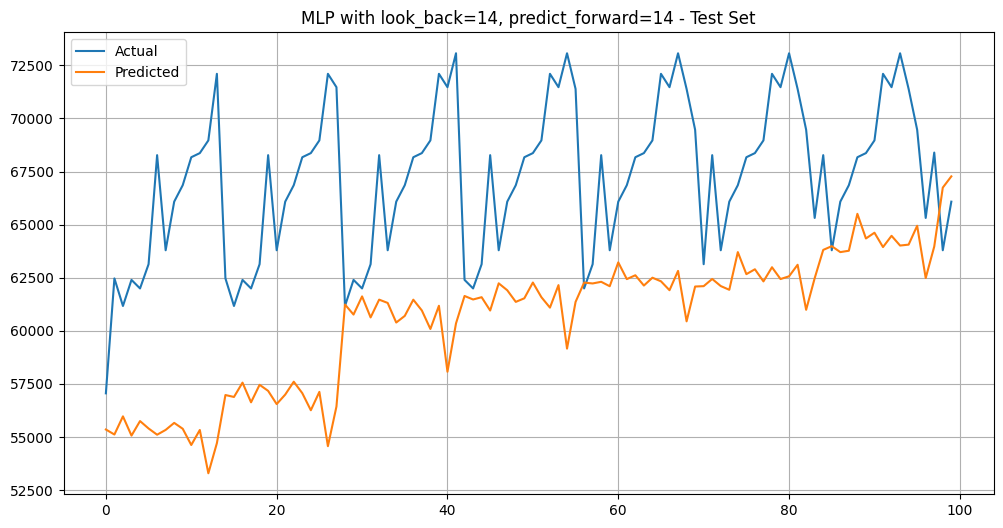


Test Set Residual Analysis:


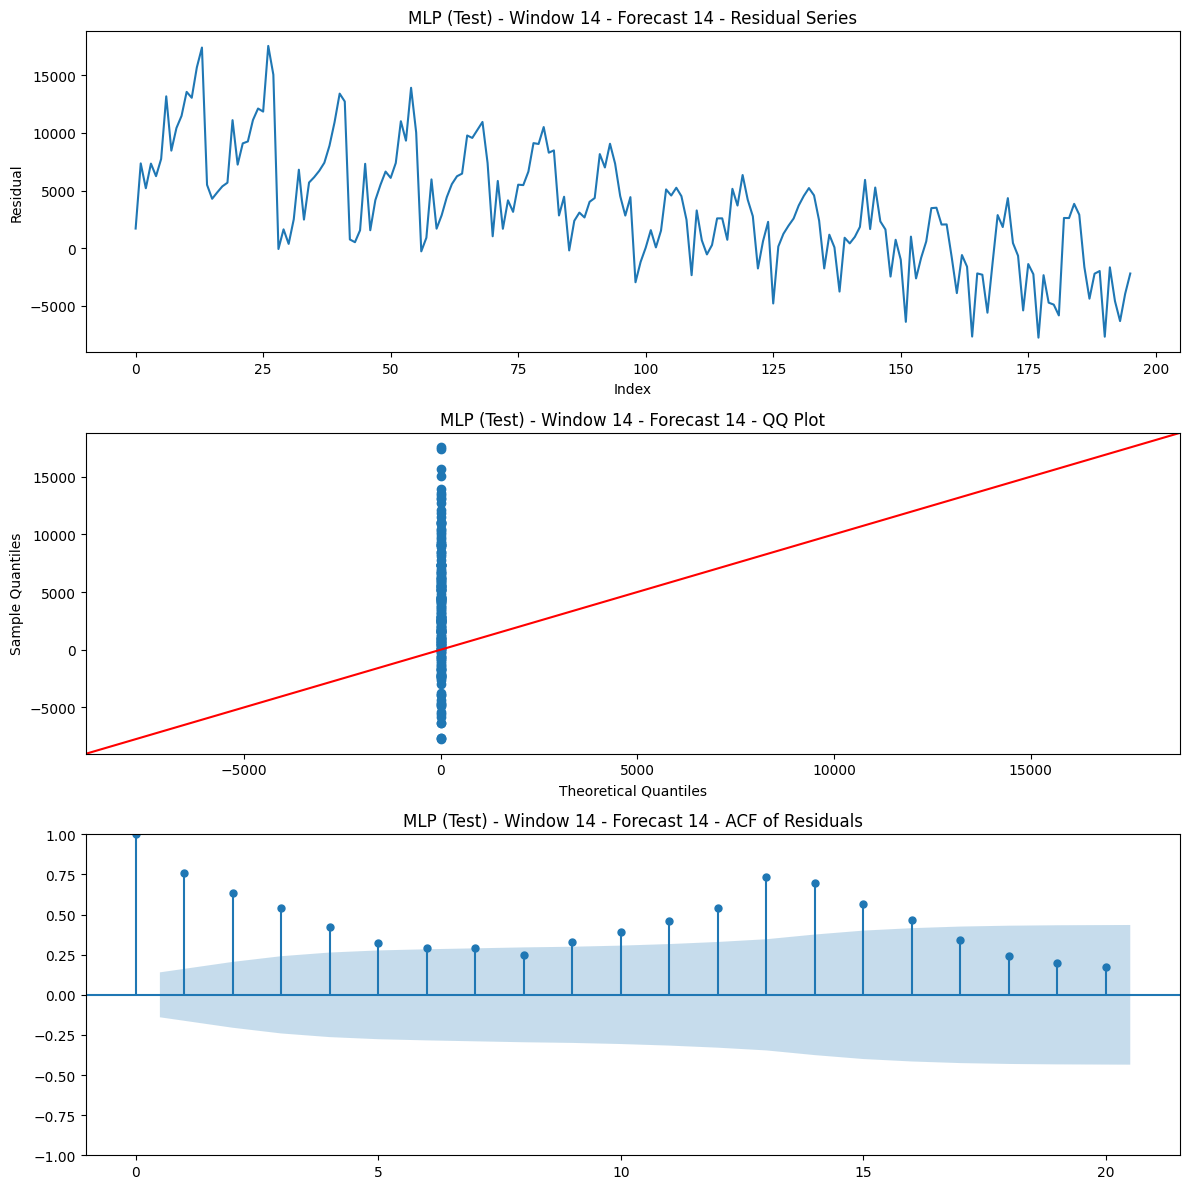


Current Model Comparison (sorted by Test RMSE):
  Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
0   MLP          7                7  4287.020486  3453.347162 -1.186213
1   RNN          7                7  4462.163558  3658.052742 -1.368494
8  LSTM         14                7  4813.947281  4118.660332 -1.756665
4   RNN          7               14  4844.318344  3838.070703 -1.091096
6   MLP         14                7  5287.117321  4476.079273 -2.325211
2  LSTM          7                7  5525.594889  4745.705899 -2.631947
7   RNN         14                7  5645.567344  4787.536256 -2.791373
9   MLP         14               14  6097.081048  4807.239979 -2.312475
5  LSTM          7               14  6872.202402  5609.097648 -3.208240
3   MLP          7               14  6882.823250  5590.008901 -3.221258

--- Training RNN (11/24) ---
Epoch 1/50
155/155 [==============================] - 2s 10ms/step - loss: 0.0200 - val_loss: 0.0434
Epoch 2/50
155/155 [========

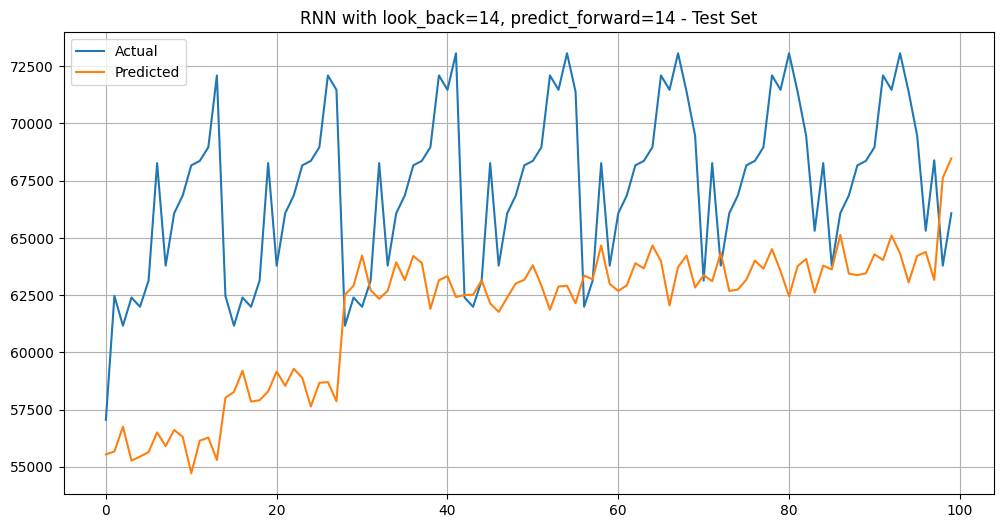


Current Model Comparison (sorted by Test RMSE):
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494
8   LSTM         14                7  4813.947281  4118.660332 -1.756665
4    RNN          7               14  4844.318344  3838.070703 -1.091096
6    MLP         14                7  5287.117321  4476.079273 -2.325211
10   RNN         14               14  5425.373259  4324.662066 -1.622816
2   LSTM          7                7  5525.594889  4745.705899 -2.631947
7    RNN         14                7  5645.567344  4787.536256 -2.791373
9    MLP         14               14  6097.081048  4807.239979 -2.312475
5   LSTM          7               14  6872.202402  5609.097648 -3.208240
3    MLP          7               14  6882.823250  5590.008901 -3.221258

--- Training LSTM (12/24) ---
Epoch 1/50
155/155 [========================

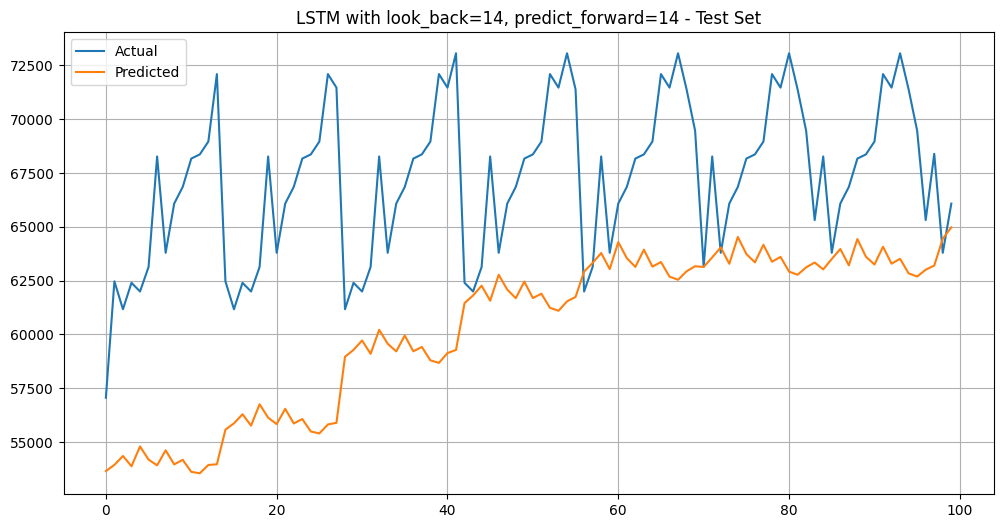


Test Set Residual Analysis:


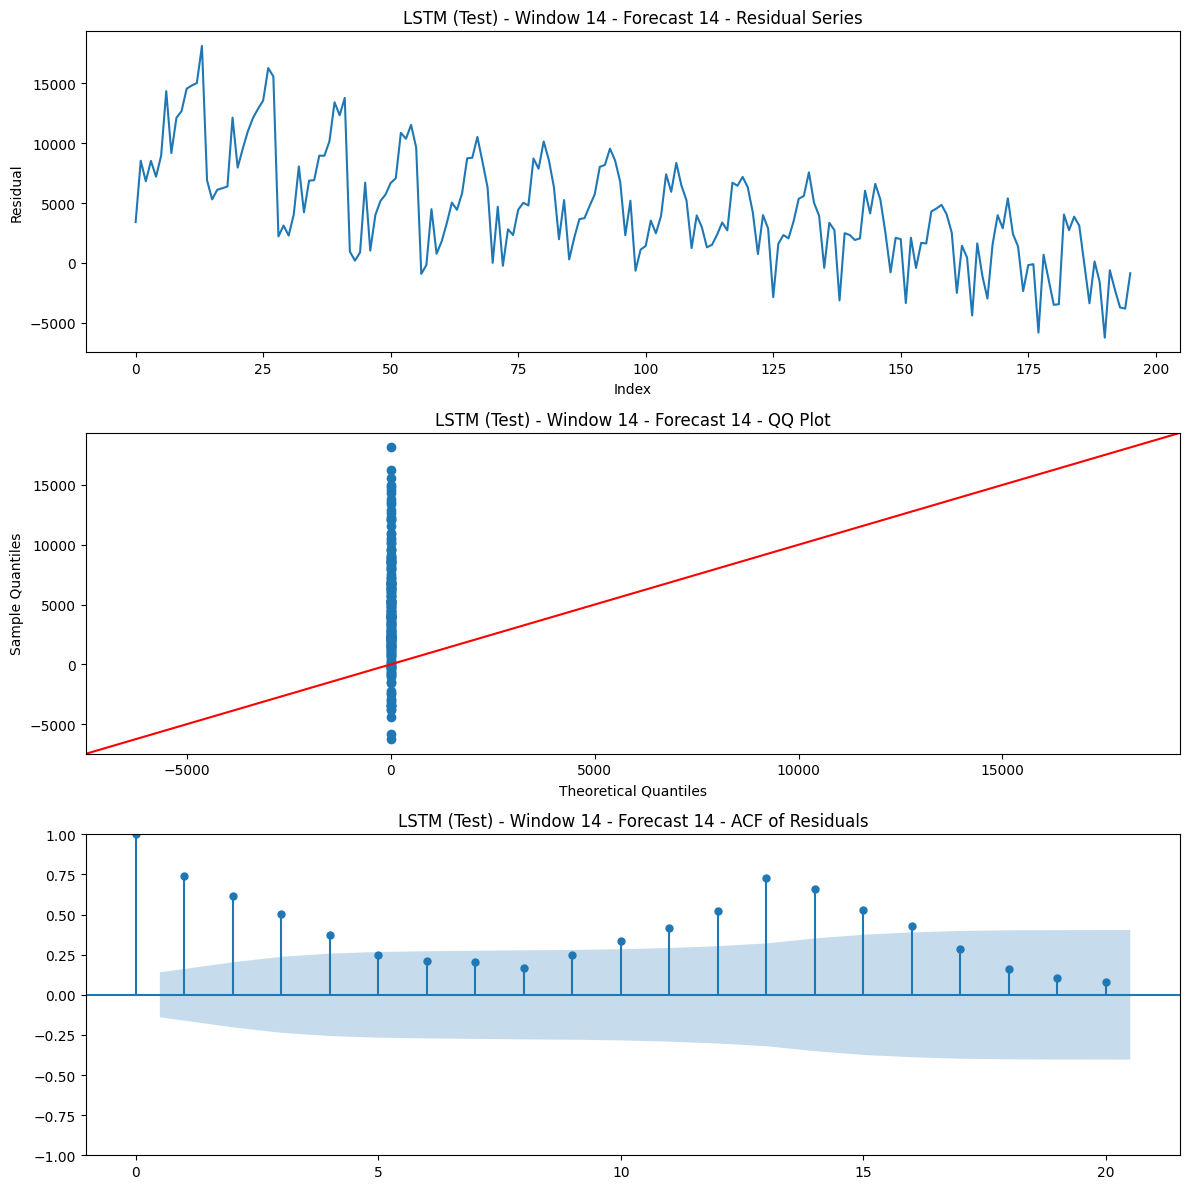


Current Model Comparison (sorted by Test RMSE):
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494
8   LSTM         14                7  4813.947281  4118.660332 -1.756665
4    RNN          7               14  4844.318344  3838.070703 -1.091096
6    MLP         14                7  5287.117321  4476.079273 -2.325211
10   RNN         14               14  5425.373259  4324.662066 -1.622816
2   LSTM          7                7  5525.594889  4745.705899 -2.631947
7    RNN         14                7  5645.567344  4787.536256 -2.791373
9    MLP         14               14  6097.081048  4807.239979 -2.312475
11  LSTM         14               14  6381.968756  5109.801104 -2.629259
5   LSTM          7               14  6872.202402  5609.097648 -3.208240
3    MLP          7               14  6882.823250  5590.008901 -3.221258


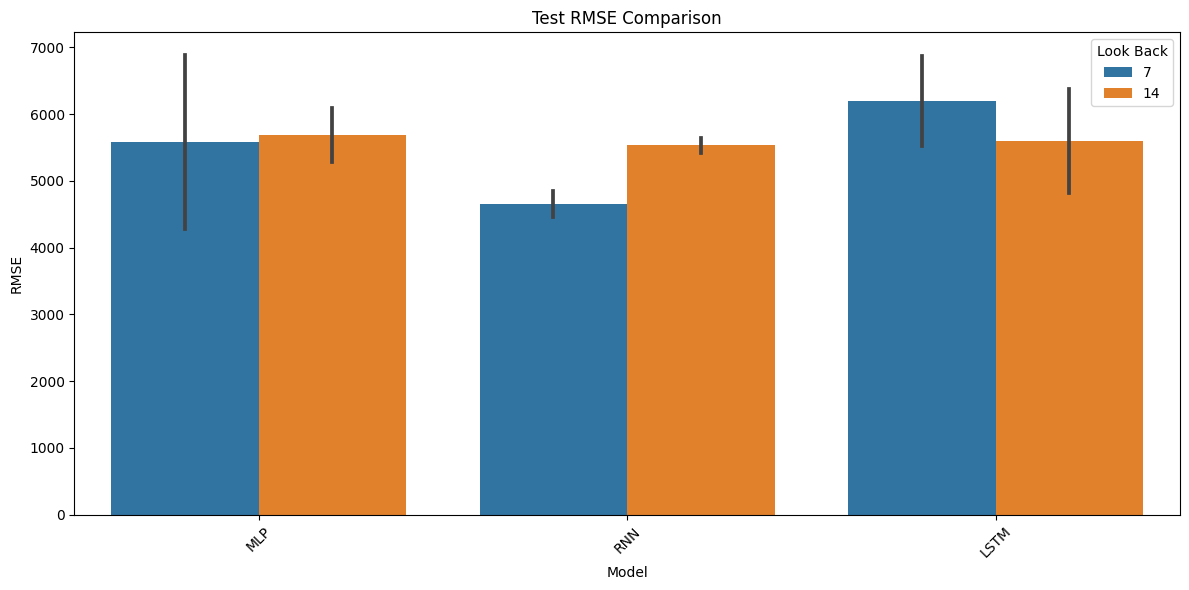


==== Testing look_back=21, predict_forward=7 ====

--- Training MLP (13/24) ---
Epoch 1/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0123 - val_loss: 0.0632
Epoch 2/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0051 - val_loss: 0.0424
Epoch 3/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0040 - val_loss: 0.0267
Epoch 4/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0033 - val_loss: 0.0128
Epoch 5/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0031 - val_loss: 0.0109
Epoch 6/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0027 - val_loss: 0.0089
Epoch 7/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0027 - val_loss: 0.0042
Epoch 8/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0024 - val_loss: 0.0153
Epoch 9/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0025 - val_loss: 0.0193
Epoch 10/50
155/155

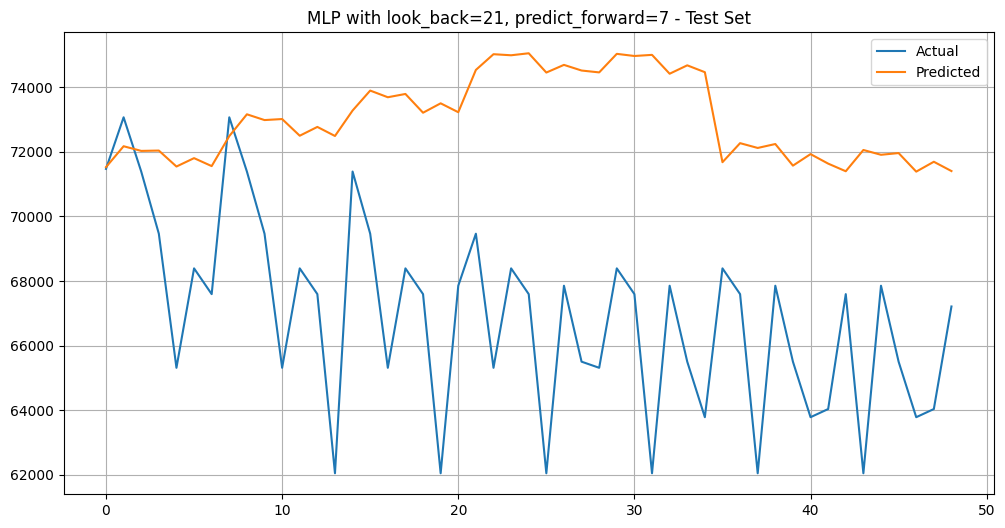


Current Model Comparison (sorted by Test RMSE):
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494
8   LSTM         14                7  4813.947281  4118.660332 -1.756665
4    RNN          7               14  4844.318344  3838.070703 -1.091096
6    MLP         14                7  5287.117321  4476.079273 -2.325211
10   RNN         14               14  5425.373259  4324.662066 -1.622816
2   LSTM          7                7  5525.594889  4745.705899 -2.631947
7    RNN         14                7  5645.567344  4787.536256 -2.791373
9    MLP         14               14  6097.081048  4807.239979 -2.312475
11  LSTM         14               14  6381.968756  5109.801104 -2.629259
5   LSTM          7               14  6872.202402  5609.097648 -3.208240
3    MLP          7               14  6882.823250  5590.008901 -3.221258
12

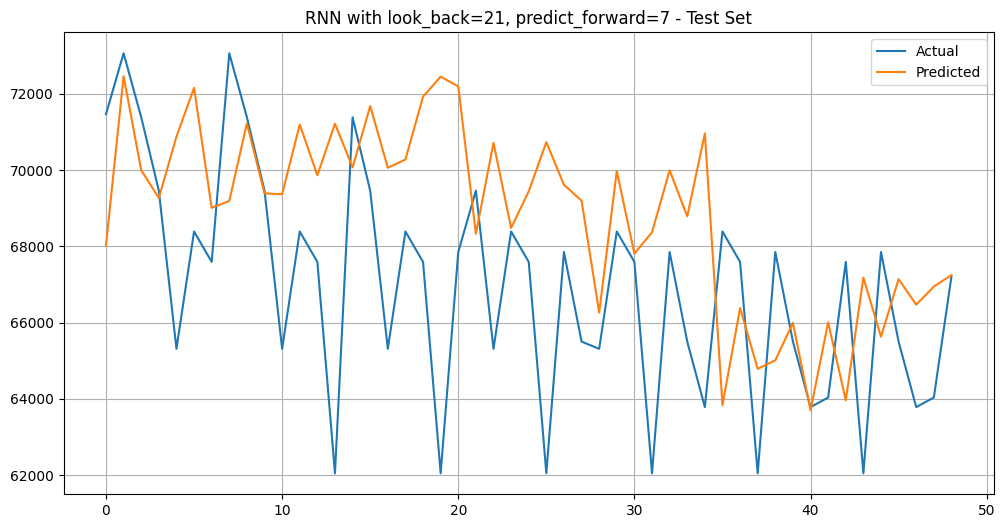


Test Set Residual Analysis:


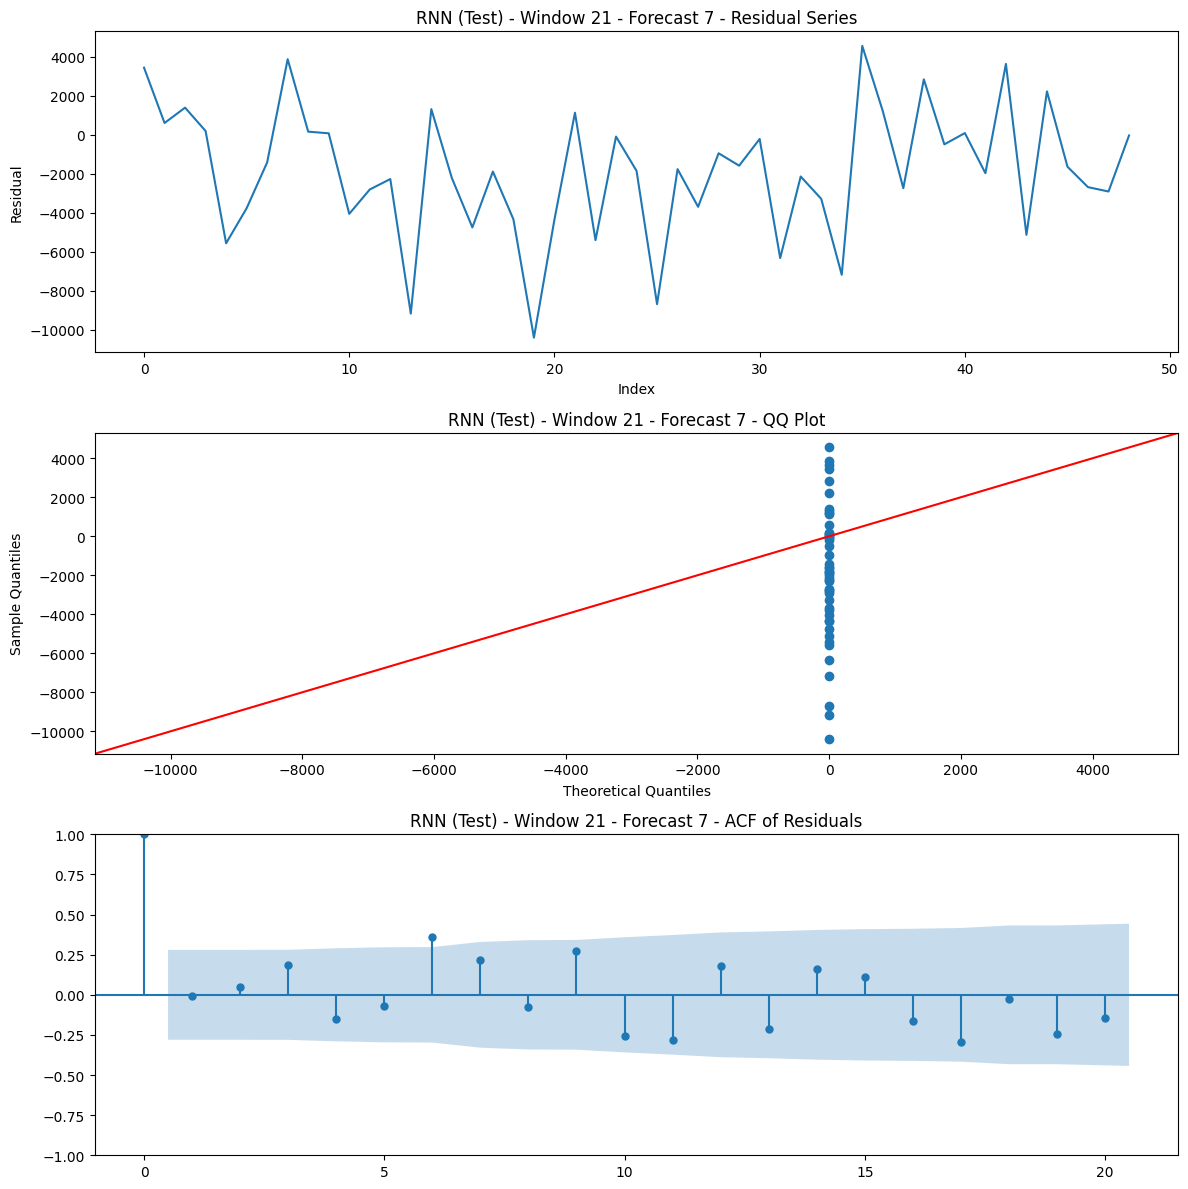


Current Model Comparison (sorted by Test RMSE):
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
13   RNN         21                7  3805.741328  2948.566916 -0.722899
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494
8   LSTM         14                7  4813.947281  4118.660332 -1.756665
4    RNN          7               14  4844.318344  3838.070703 -1.091096
6    MLP         14                7  5287.117321  4476.079273 -2.325211
10   RNN         14               14  5425.373259  4324.662066 -1.622816
2   LSTM          7                7  5525.594889  4745.705899 -2.631947
7    RNN         14                7  5645.567344  4787.536256 -2.791373
9    MLP         14               14  6097.081048  4807.239979 -2.312475
11  LSTM         14               14  6381.968756  5109.801104 -2.629259
5   LSTM          7               14  6872.202402  5609.097648 -3.208240
3 

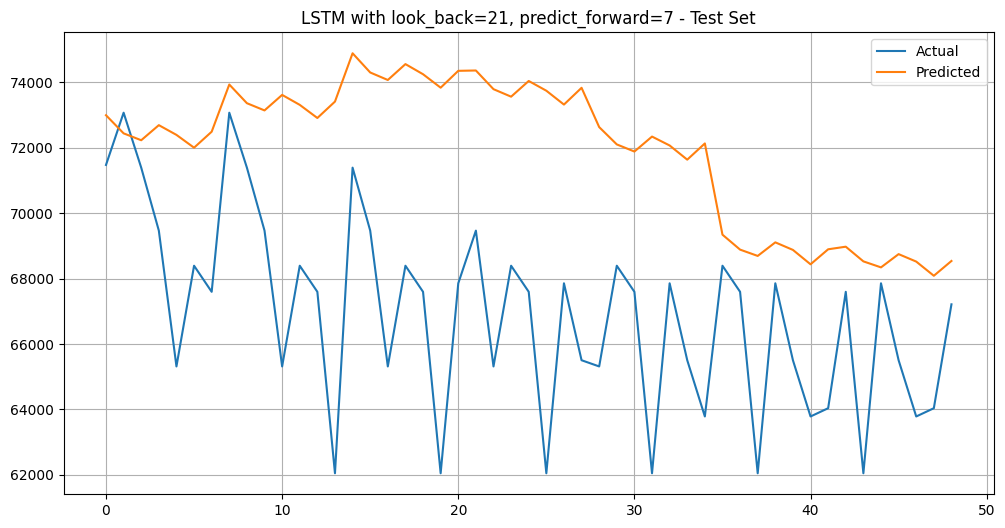


Current Model Comparison (sorted by Test RMSE):
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
13   RNN         21                7  3805.741328  2948.566916 -0.722899
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494
8   LSTM         14                7  4813.947281  4118.660332 -1.756665
4    RNN          7               14  4844.318344  3838.070703 -1.091096
6    MLP         14                7  5287.117321  4476.079273 -2.325211
10   RNN         14               14  5425.373259  4324.662066 -1.622816
2   LSTM          7                7  5525.594889  4745.705899 -2.631947
7    RNN         14                7  5645.567344  4787.536256 -2.791373
14  LSTM         21                7  5820.353216  5014.823374 -3.029768
9    MLP         14               14  6097.081048  4807.239979 -2.312475
11  LSTM         14               14  6381.968756  5109.801104 -2.629259
5 

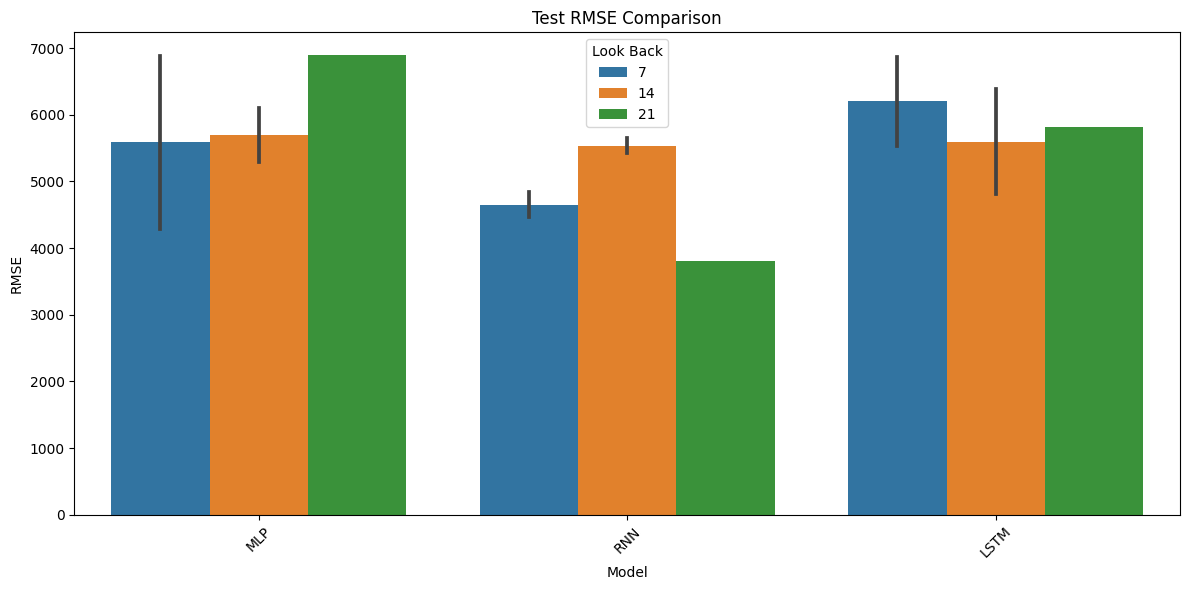


==== Testing look_back=21, predict_forward=14 ====

--- Training MLP (16/24) ---
Epoch 1/50
155/155 [==============================] - 1s 2ms/step - loss: 0.0162 - val_loss: 0.0619
Epoch 2/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0060 - val_loss: 0.0455
Epoch 3/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0046 - val_loss: 0.0271
Epoch 4/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0035 - val_loss: 0.0216
Epoch 5/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0032 - val_loss: 0.0139
Epoch 6/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0031 - val_loss: 0.0176
Epoch 7/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0031 - val_loss: 0.0155
Epoch 8/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0027 - val_loss: 0.0366
Epoch 9/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0028 - val_loss: 0.0280
Epoch 10/50
155/15

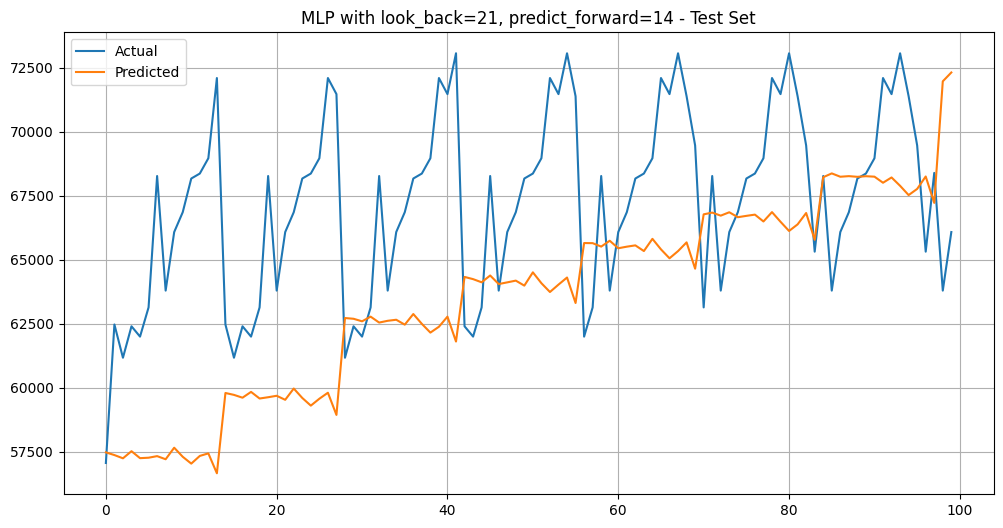


Test Set Residual Analysis:


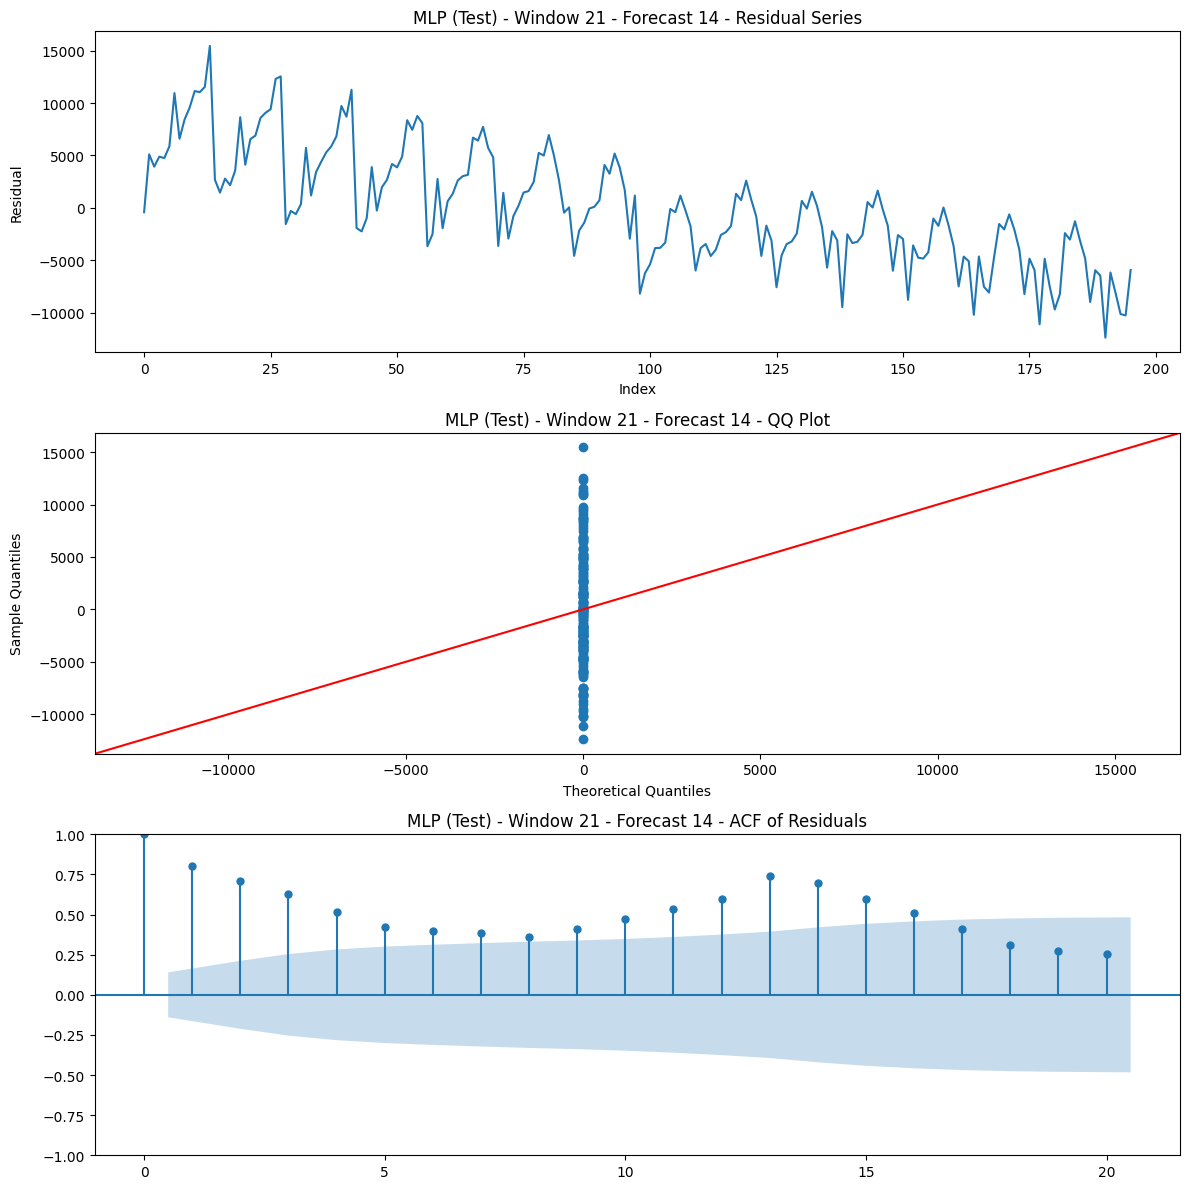


Current Model Comparison (sorted by Test RMSE):
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
13   RNN         21                7  3805.741328  2948.566916 -0.722899
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494
8   LSTM         14                7  4813.947281  4118.660332 -1.756665
4    RNN          7               14  4844.318344  3838.070703 -1.091096
6    MLP         14                7  5287.117321  4476.079273 -2.325211
15   MLP         21               14  5373.807268  4323.840123 -1.573196
10   RNN         14               14  5425.373259  4324.662066 -1.622816
2   LSTM          7                7  5525.594889  4745.705899 -2.631947
7    RNN         14                7  5645.567344  4787.536256 -2.791373
14  LSTM         21                7  5820.353216  5014.823374 -3.029768
9    MLP         14               14  6097.081048  4807.239979 -2.312475
11

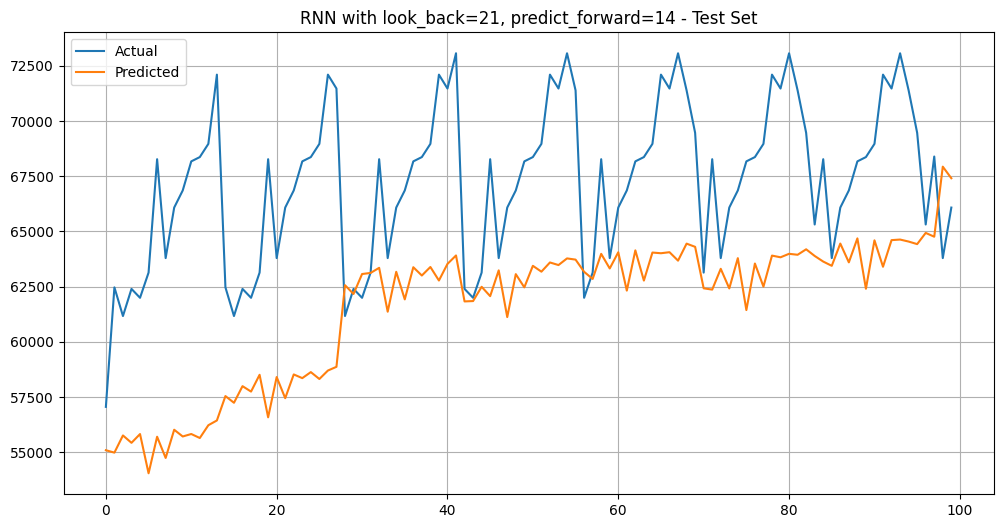


Current Model Comparison (sorted by Test RMSE):
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
13   RNN         21                7  3805.741328  2948.566916 -0.722899
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494
8   LSTM         14                7  4813.947281  4118.660332 -1.756665
4    RNN          7               14  4844.318344  3838.070703 -1.091096
6    MLP         14                7  5287.117321  4476.079273 -2.325211
15   MLP         21               14  5373.807268  4323.840123 -1.573196
10   RNN         14               14  5425.373259  4324.662066 -1.622816
16   RNN         21               14  5464.726869  4399.062516 -1.661004
2   LSTM          7                7  5525.594889  4745.705899 -2.631947
7    RNN         14                7  5645.567344  4787.536256 -2.791373
14  LSTM         21                7  5820.353216  5014.823374 -3.029768
9 

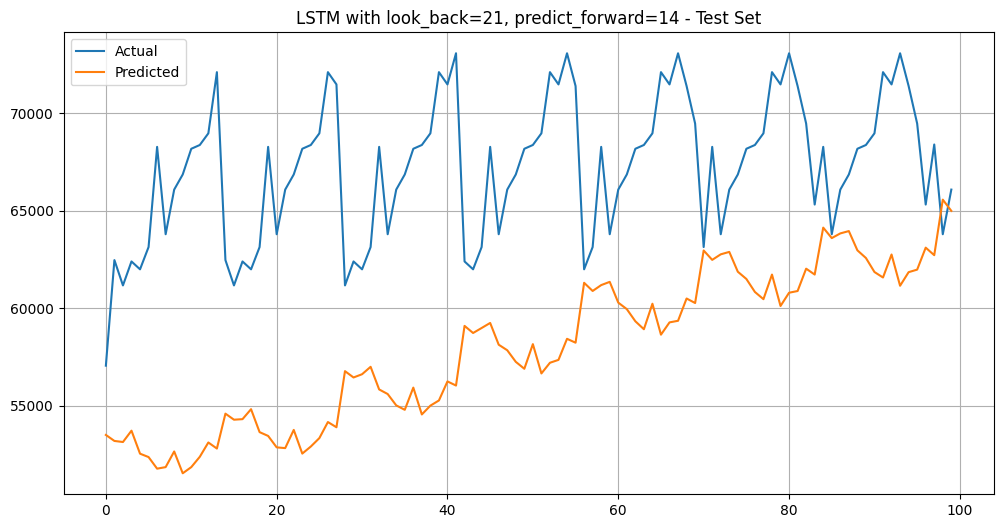


Test Set Residual Analysis:


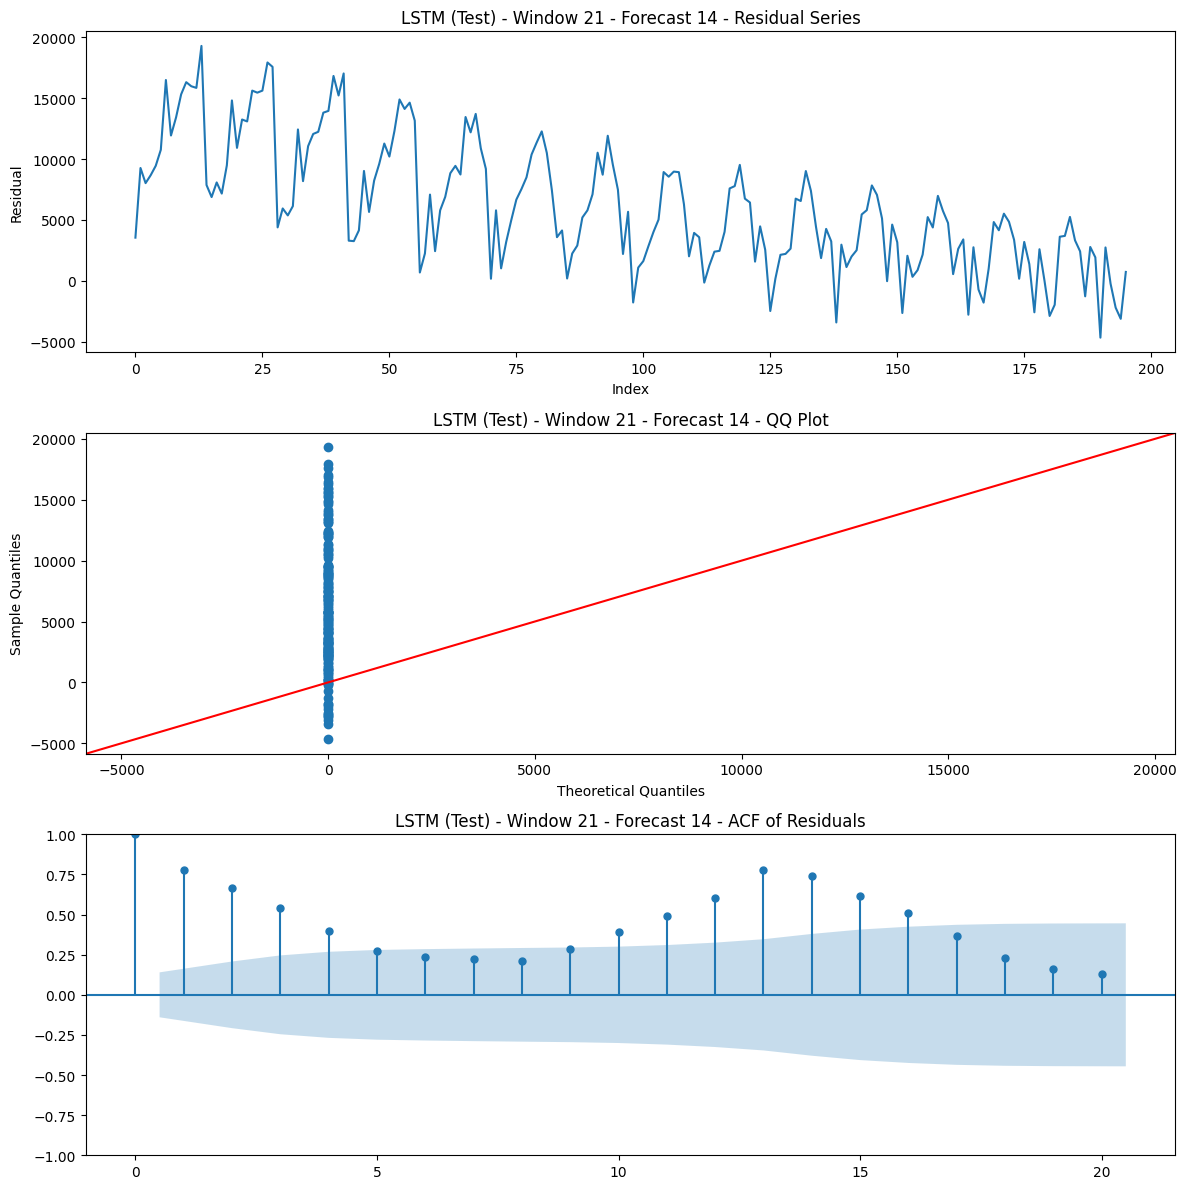


Current Model Comparison (sorted by Test RMSE):
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
13   RNN         21                7  3805.741328  2948.566916 -0.722899
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494
8   LSTM         14                7  4813.947281  4118.660332 -1.756665
4    RNN          7               14  4844.318344  3838.070703 -1.091096
6    MLP         14                7  5287.117321  4476.079273 -2.325211
15   MLP         21               14  5373.807268  4323.840123 -1.573196
10   RNN         14               14  5425.373259  4324.662066 -1.622816
16   RNN         21               14  5464.726869  4399.062516 -1.661004
2   LSTM          7                7  5525.594889  4745.705899 -2.631947
7    RNN         14                7  5645.567344  4787.536256 -2.791373
14  LSTM         21                7  5820.353216  5014.823374 -3.029768
9 

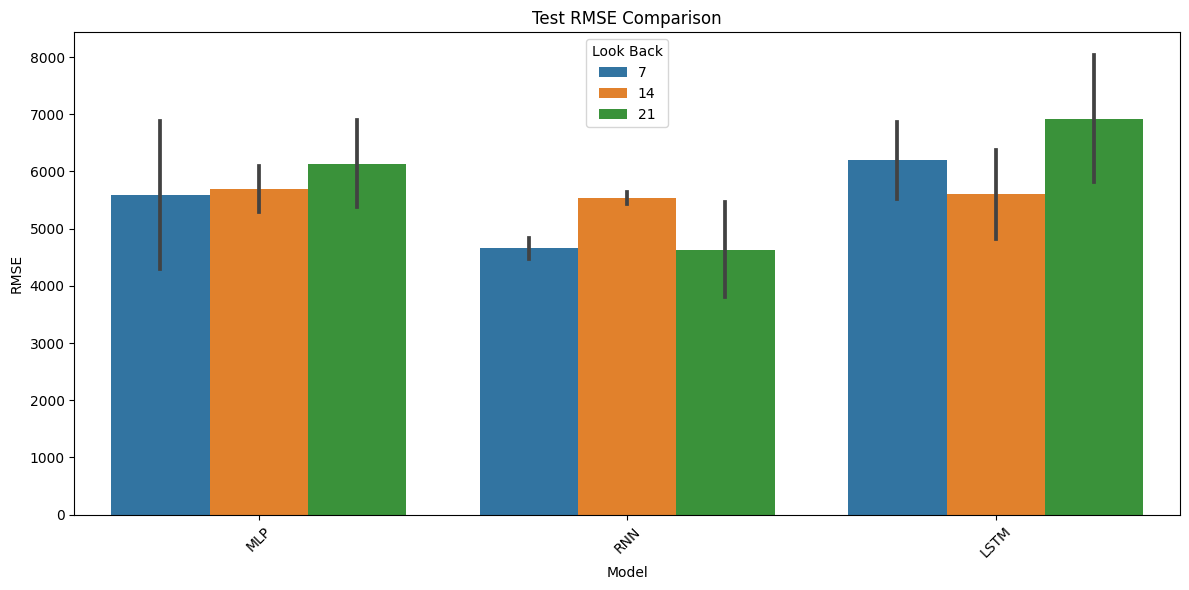


==== Testing look_back=28, predict_forward=7 ====

--- Training MLP (19/24) ---
Epoch 1/50
155/155 [==============================] - 1s 2ms/step - loss: 0.0154 - val_loss: 0.0542
Epoch 2/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0054 - val_loss: 0.0417
Epoch 3/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0040 - val_loss: 0.0263
Epoch 4/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0036 - val_loss: 0.0229
Epoch 5/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0035 - val_loss: 0.0204
Epoch 6/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0030 - val_loss: 0.0155
Epoch 7/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0031 - val_loss: 0.0090
Epoch 8/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0027 - val_loss: 0.0291
Epoch 9/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0027 - val_loss: 0.0080
Epoch 10/50
155/155

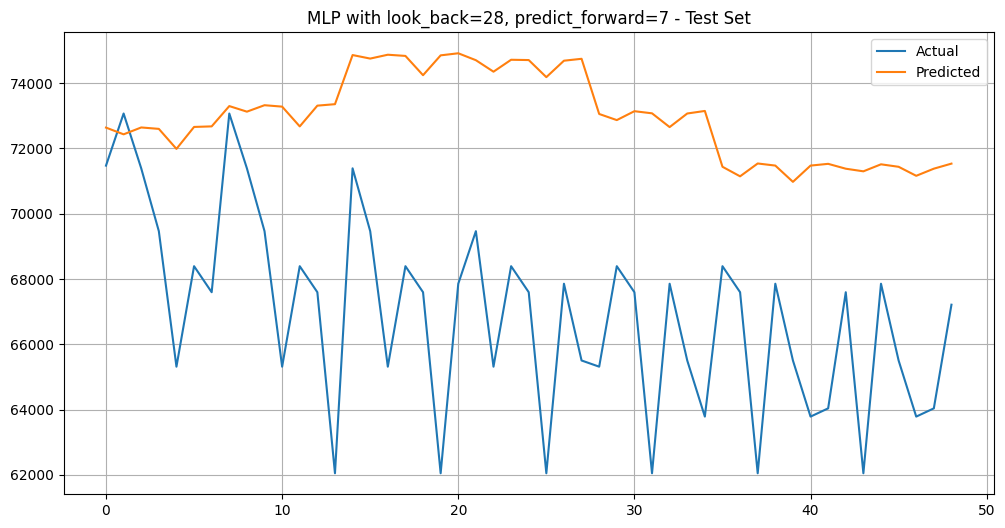


Current Model Comparison (sorted by Test RMSE):
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
13   RNN         21                7  3805.741328  2948.566916 -0.722899
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494
8   LSTM         14                7  4813.947281  4118.660332 -1.756665
4    RNN          7               14  4844.318344  3838.070703 -1.091096
6    MLP         14                7  5287.117321  4476.079273 -2.325211
15   MLP         21               14  5373.807268  4323.840123 -1.573196
10   RNN         14               14  5425.373259  4324.662066 -1.622816
16   RNN         21               14  5464.726869  4399.062516 -1.661004
2   LSTM          7                7  5525.594889  4745.705899 -2.631947
7    RNN         14                7  5645.567344  4787.536256 -2.791373
14  LSTM         21                7  5820.353216  5014.823374 -3.029768
9 

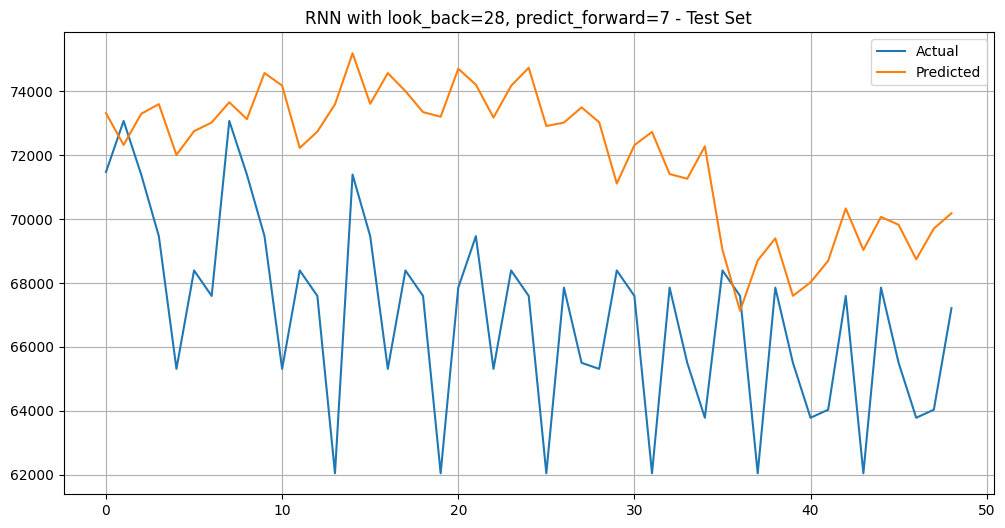


Test Set Residual Analysis:


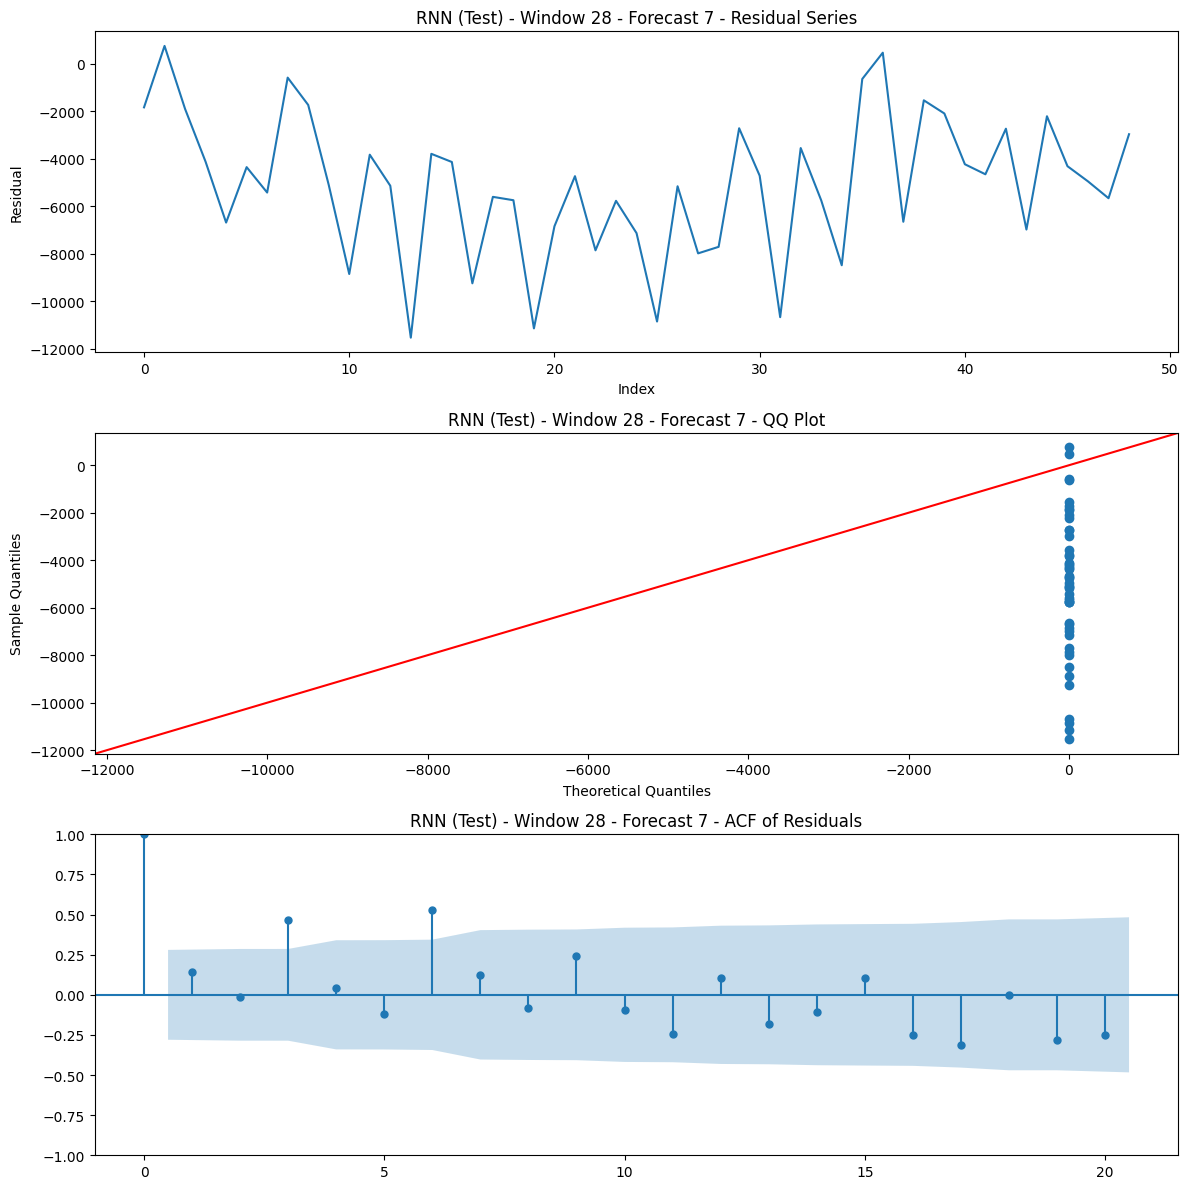


Current Model Comparison (sorted by Test RMSE):
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
13   RNN         21                7  3805.741328  2948.566916 -0.722899
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494
8   LSTM         14                7  4813.947281  4118.660332 -1.756665
4    RNN          7               14  4844.318344  3838.070703 -1.091096
6    MLP         14                7  5287.117321  4476.079273 -2.325211
15   MLP         21               14  5373.807268  4323.840123 -1.573196
10   RNN         14               14  5425.373259  4324.662066 -1.622816
16   RNN         21               14  5464.726869  4399.062516 -1.661004
2   LSTM          7                7  5525.594889  4745.705899 -2.631947
7    RNN         14                7  5645.567344  4787.536256 -2.791373
14  LSTM         21                7  5820.353216  5014.823374 -3.029768
19

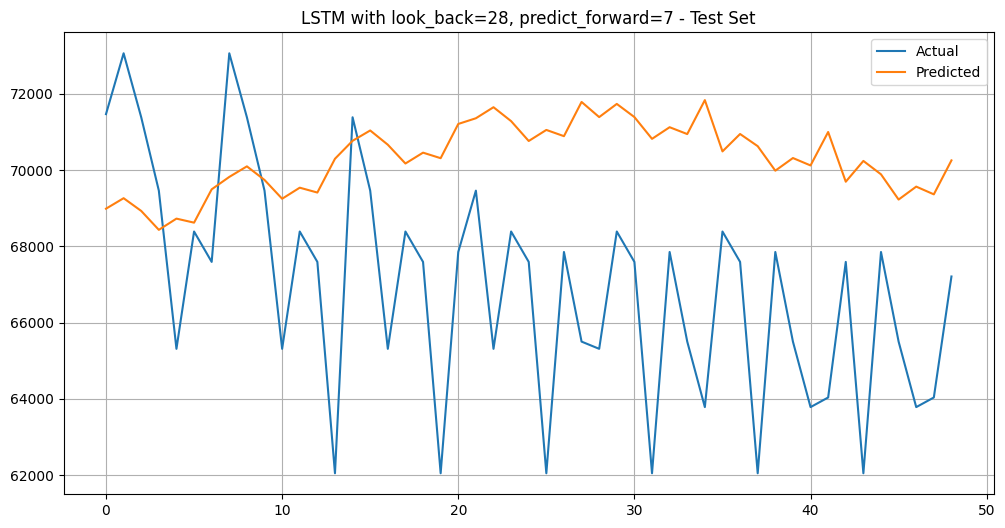


Current Model Comparison (sorted by Test RMSE):
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
13   RNN         21                7  3805.741328  2948.566916 -0.722899
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494
20  LSTM         28                7  4671.020144  3979.611352 -1.595403
8   LSTM         14                7  4813.947281  4118.660332 -1.756665
4    RNN          7               14  4844.318344  3838.070703 -1.091096
6    MLP         14                7  5287.117321  4476.079273 -2.325211
15   MLP         21               14  5373.807268  4323.840123 -1.573196
10   RNN         14               14  5425.373259  4324.662066 -1.622816
16   RNN         21               14  5464.726869  4399.062516 -1.661004
2   LSTM          7                7  5525.594889  4745.705899 -2.631947
7    RNN         14                7  5645.567344  4787.536256 -2.791373
14

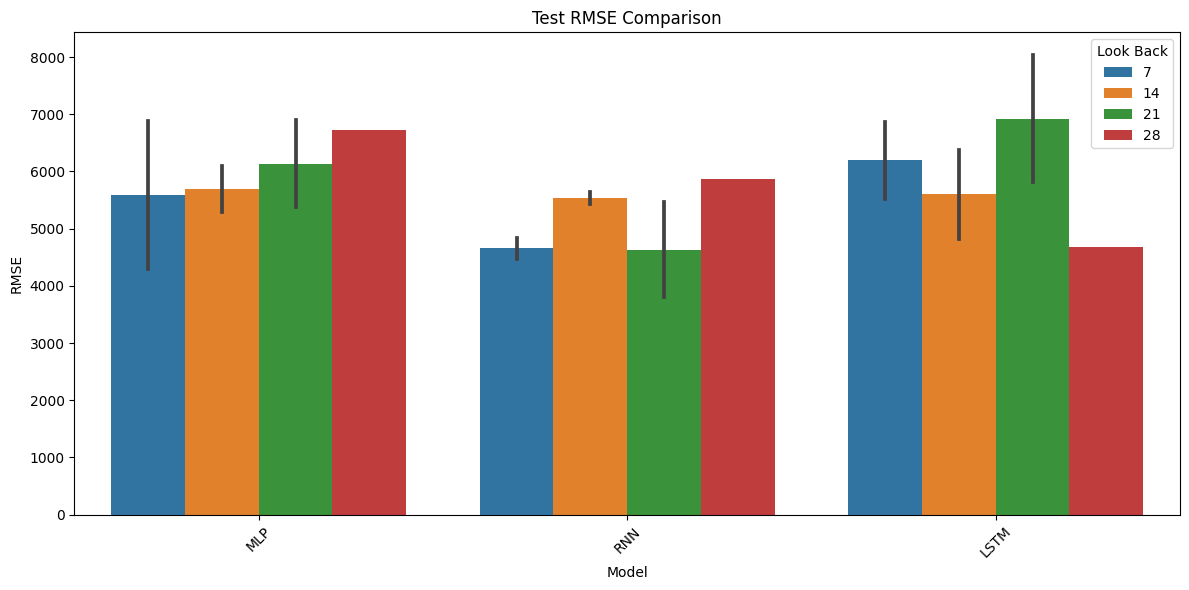


==== Testing look_back=28, predict_forward=14 ====

--- Training MLP (22/24) ---
Epoch 1/50
155/155 [==============================] - 1s 2ms/step - loss: 0.0172 - val_loss: 0.0522
Epoch 2/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0056 - val_loss: 0.0151
Epoch 3/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0037 - val_loss: 0.0268
Epoch 4/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0034 - val_loss: 0.0218
Epoch 5/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0032 - val_loss: 0.0131
Epoch 6/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0030 - val_loss: 0.0227
Epoch 7/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0029 - val_loss: 0.0134
Epoch 8/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0029 - val_loss: 0.0123
Epoch 9/50
155/155 [==============================] - 0s 1ms/step - loss: 0.0028 - val_loss: 0.0282
Epoch 10/50
155/15

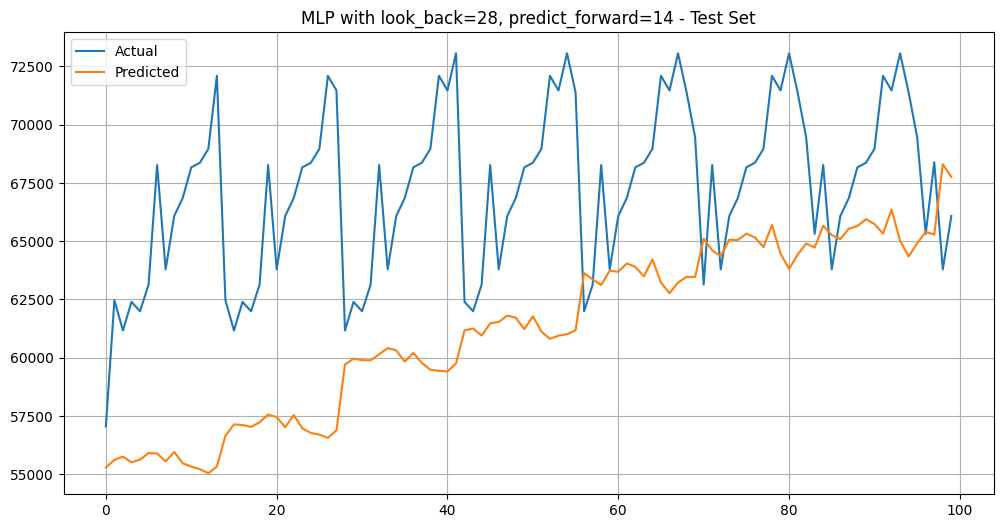


Test Set Residual Analysis:


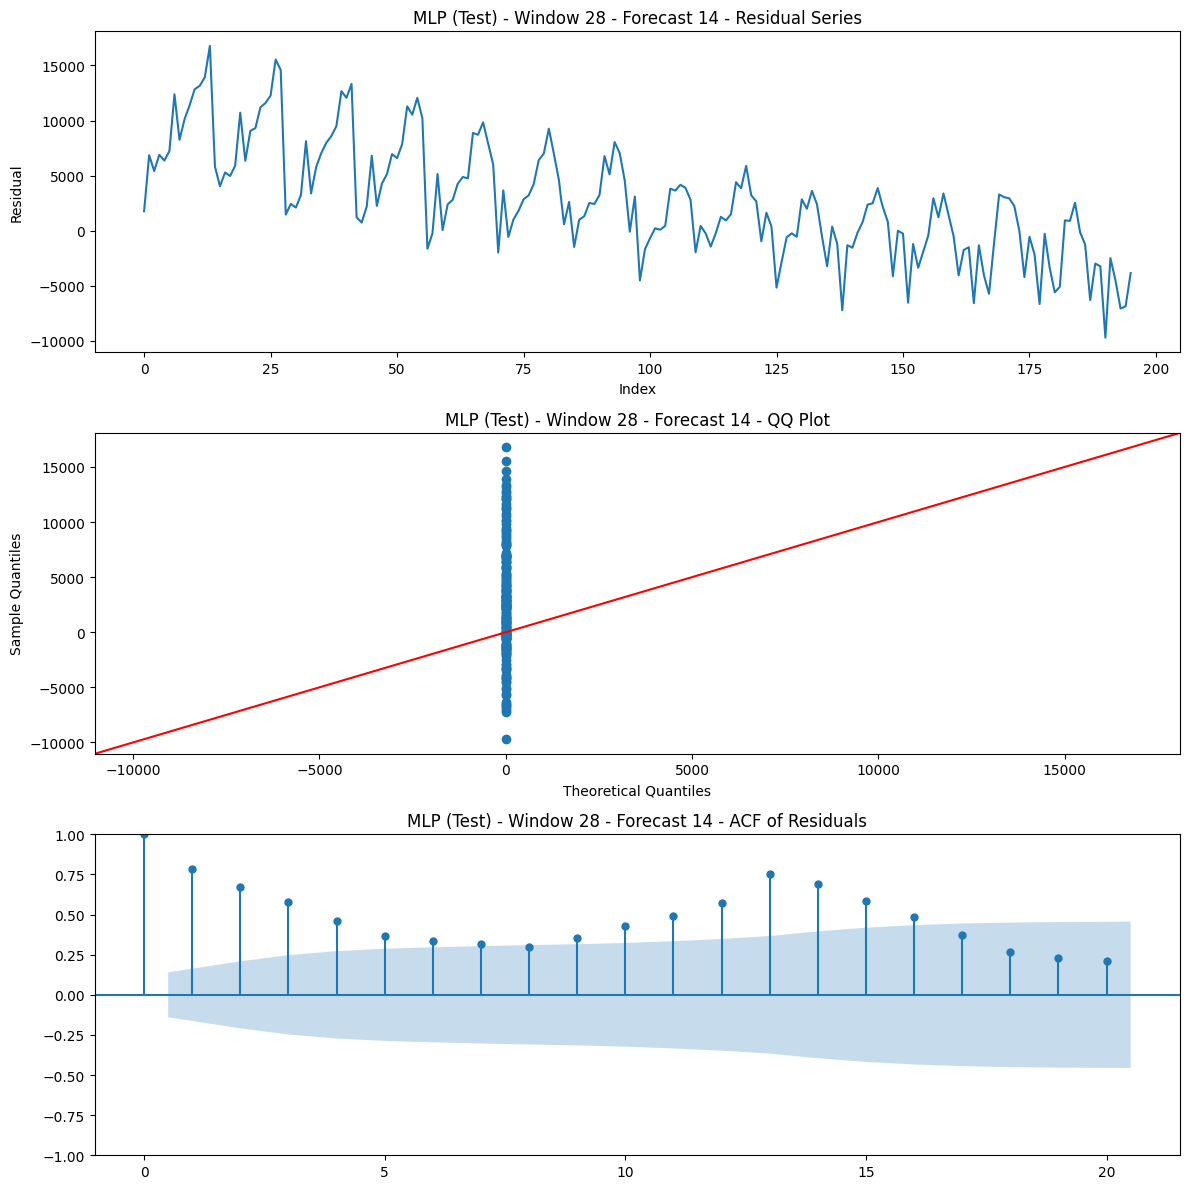


Current Model Comparison (sorted by Test RMSE):
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
13   RNN         21                7  3805.741328  2948.566916 -0.722899
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494
20  LSTM         28                7  4671.020144  3979.611352 -1.595403
8   LSTM         14                7  4813.947281  4118.660332 -1.756665
4    RNN          7               14  4844.318344  3838.070703 -1.091096
6    MLP         14                7  5287.117321  4476.079273 -2.325211
15   MLP         21               14  5373.807268  4323.840123 -1.573196
10   RNN         14               14  5425.373259  4324.662066 -1.622816
16   RNN         21               14  5464.726869  4399.062516 -1.661004
2   LSTM          7                7  5525.594889  4745.705899 -2.631947
7    RNN         14                7  5645.567344  4787.536256 -2.791373
21

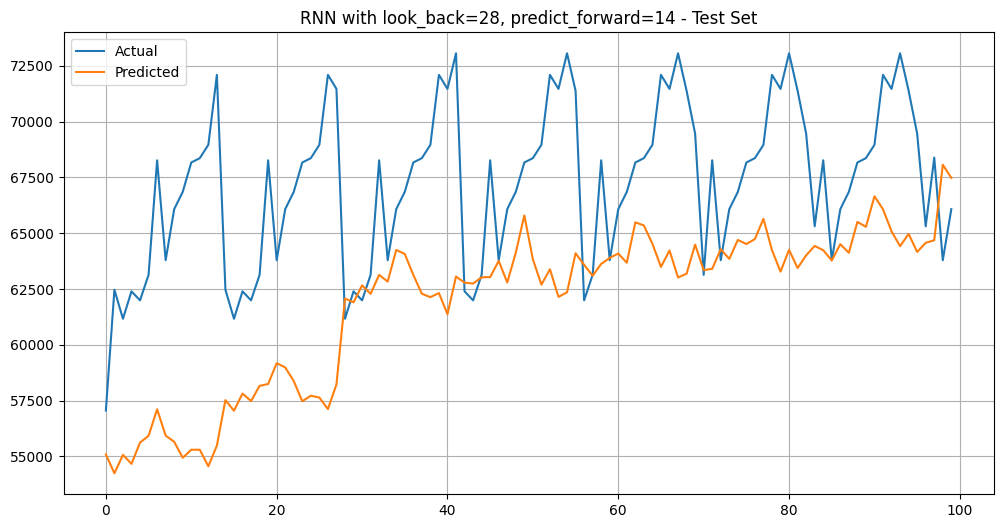


Current Model Comparison (sorted by Test RMSE):
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
13   RNN         21                7  3805.741328  2948.566916 -0.722899
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494
20  LSTM         28                7  4671.020144  3979.611352 -1.595403
8   LSTM         14                7  4813.947281  4118.660332 -1.756665
4    RNN          7               14  4844.318344  3838.070703 -1.091096
6    MLP         14                7  5287.117321  4476.079273 -2.325211
22   RNN         28               14  5355.360756  4150.534714 -1.555560
15   MLP         21               14  5373.807268  4323.840123 -1.573196
10   RNN         14               14  5425.373259  4324.662066 -1.622816
16   RNN         21               14  5464.726869  4399.062516 -1.661004
2   LSTM          7                7  5525.594889  4745.705899 -2.631947
7 

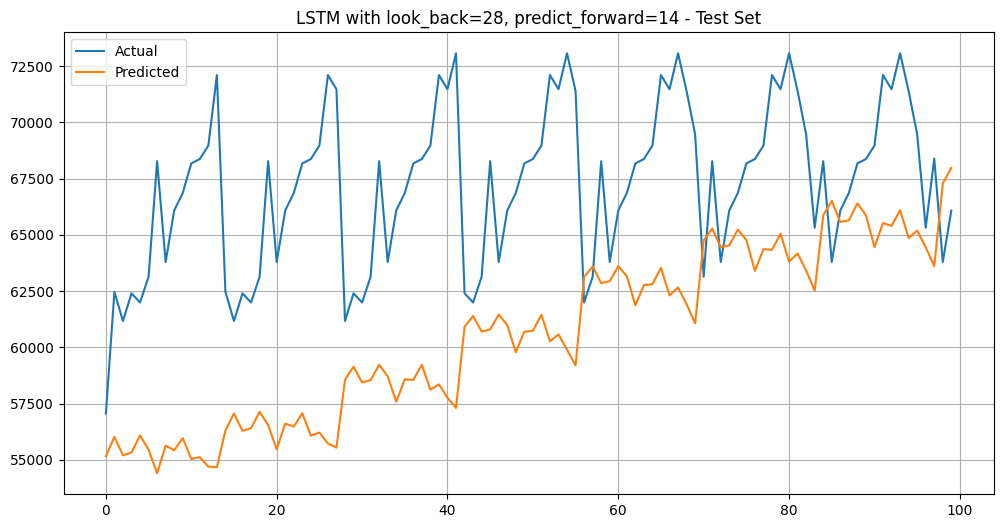


Test Set Residual Analysis:


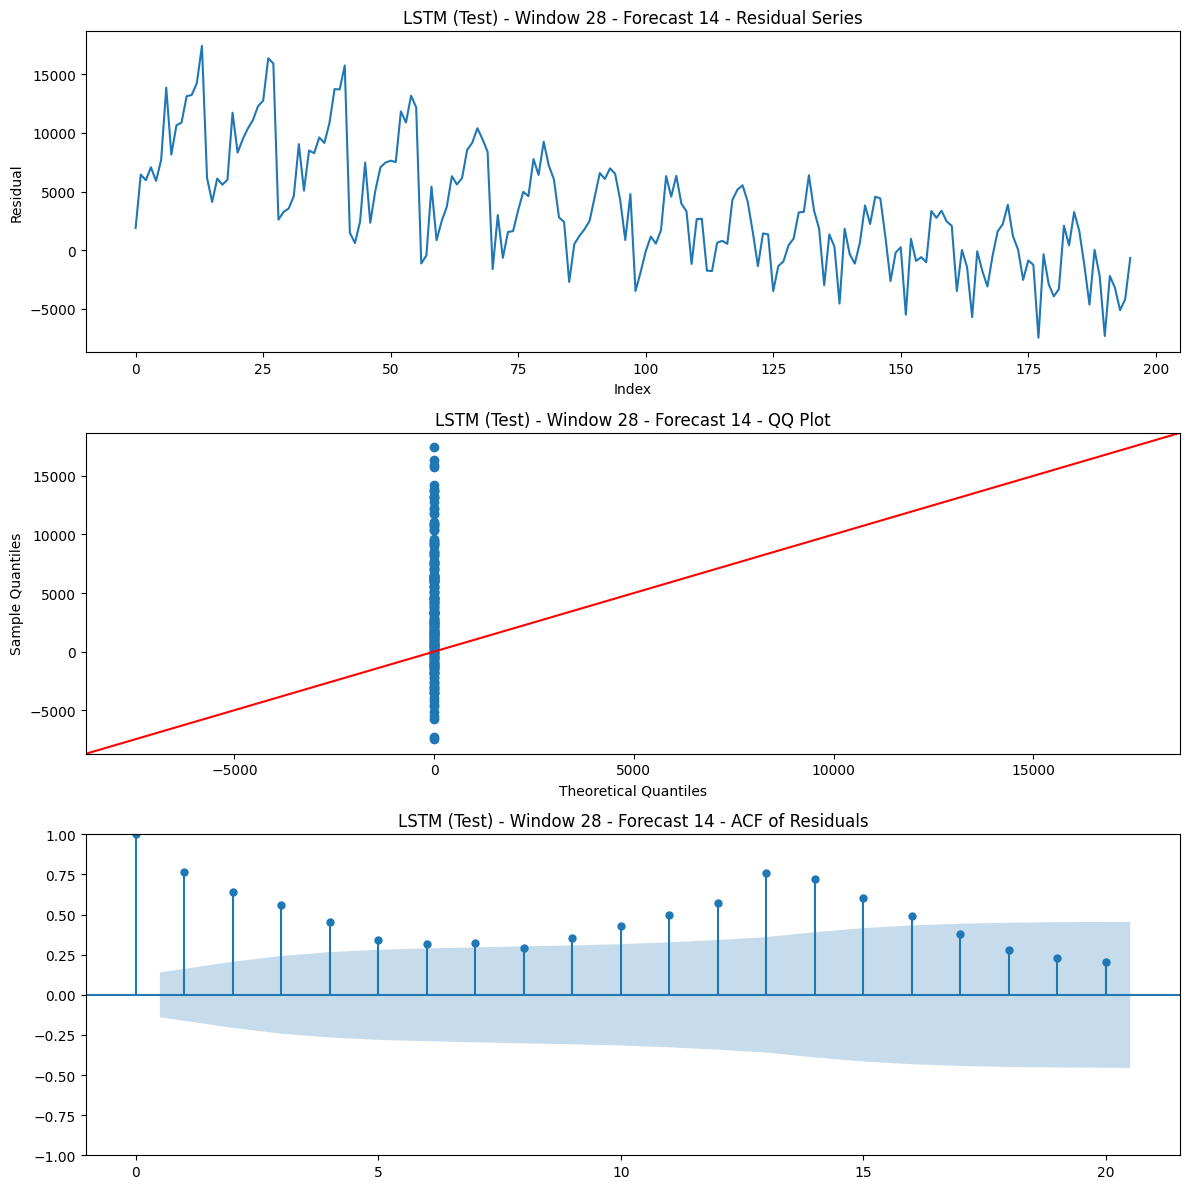


Current Model Comparison (sorted by Test RMSE):
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
13   RNN         21                7  3805.741328  2948.566916 -0.722899
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494
20  LSTM         28                7  4671.020144  3979.611352 -1.595403
8   LSTM         14                7  4813.947281  4118.660332 -1.756665
4    RNN          7               14  4844.318344  3838.070703 -1.091096
6    MLP         14                7  5287.117321  4476.079273 -2.325211
22   RNN         28               14  5355.360756  4150.534714 -1.555560
15   MLP         21               14  5373.807268  4323.840123 -1.573196
10   RNN         14               14  5425.373259  4324.662066 -1.622816
16   RNN         21               14  5464.726869  4399.062516 -1.661004
2   LSTM          7                7  5525.594889  4745.705899 -2.631947
7 

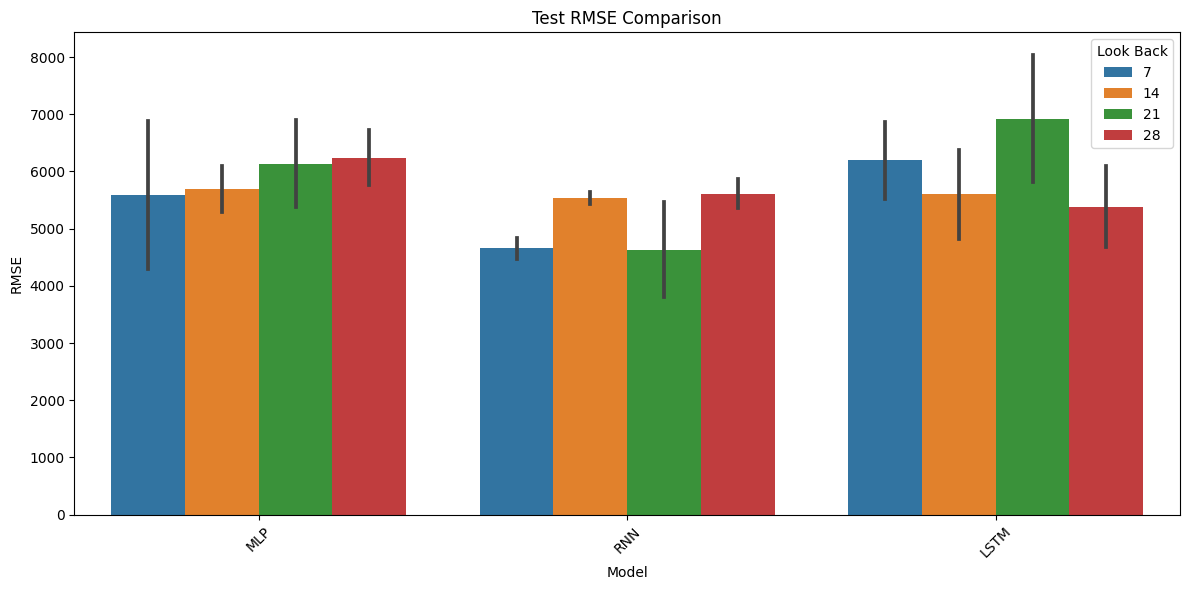


===== Final Results Visualization =====


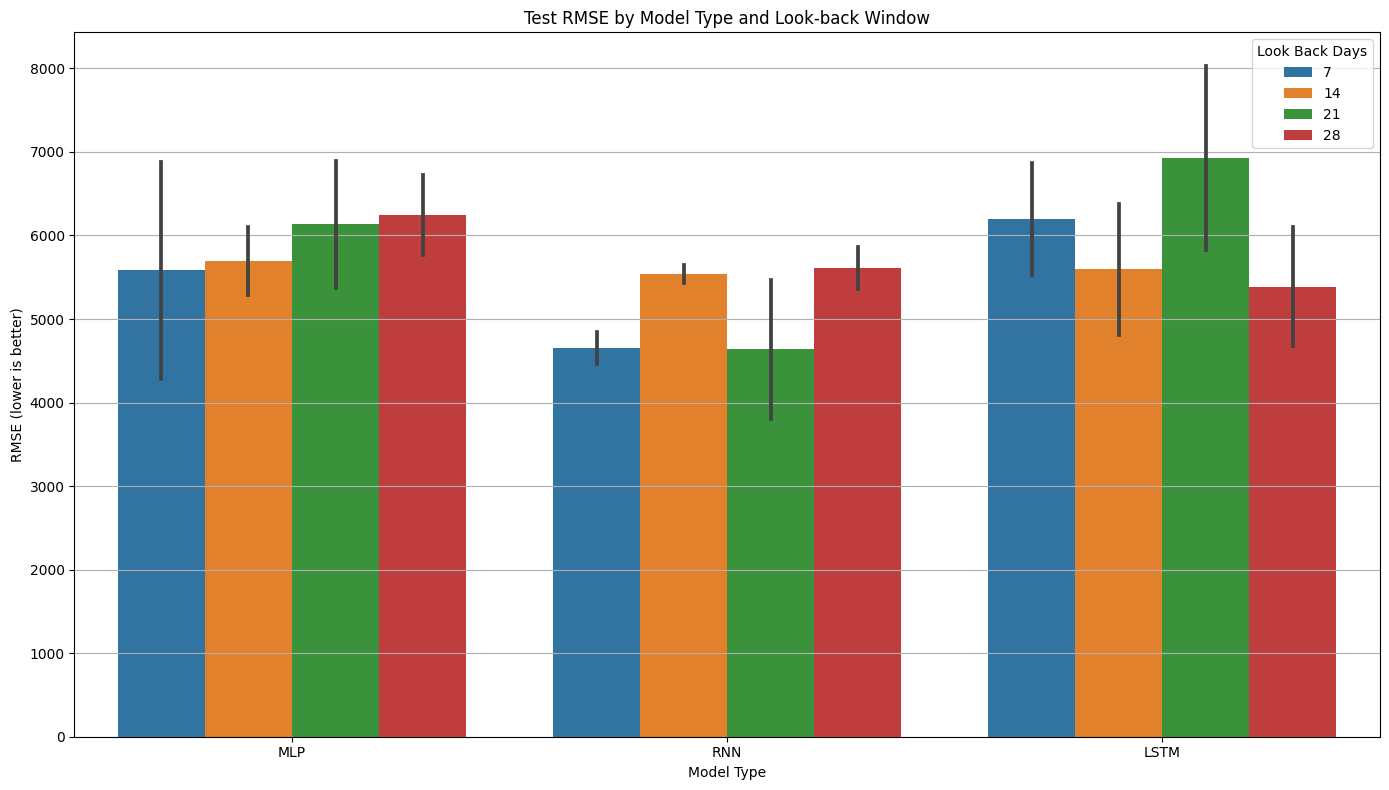

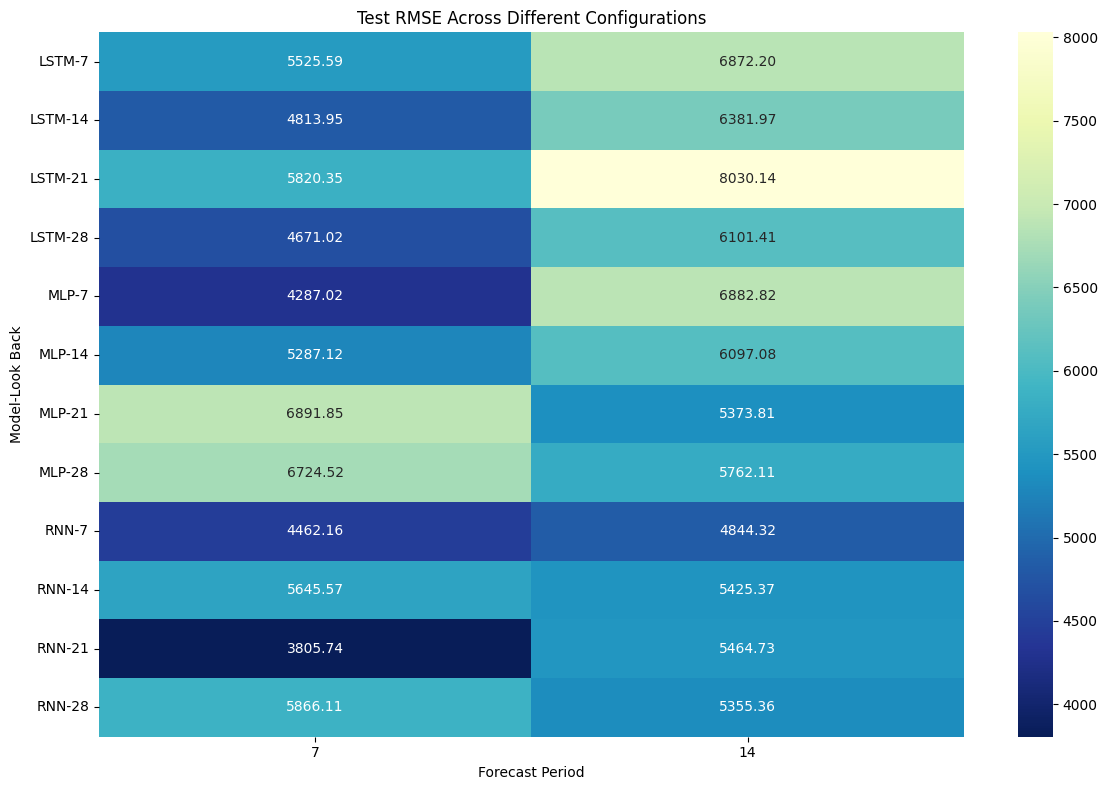

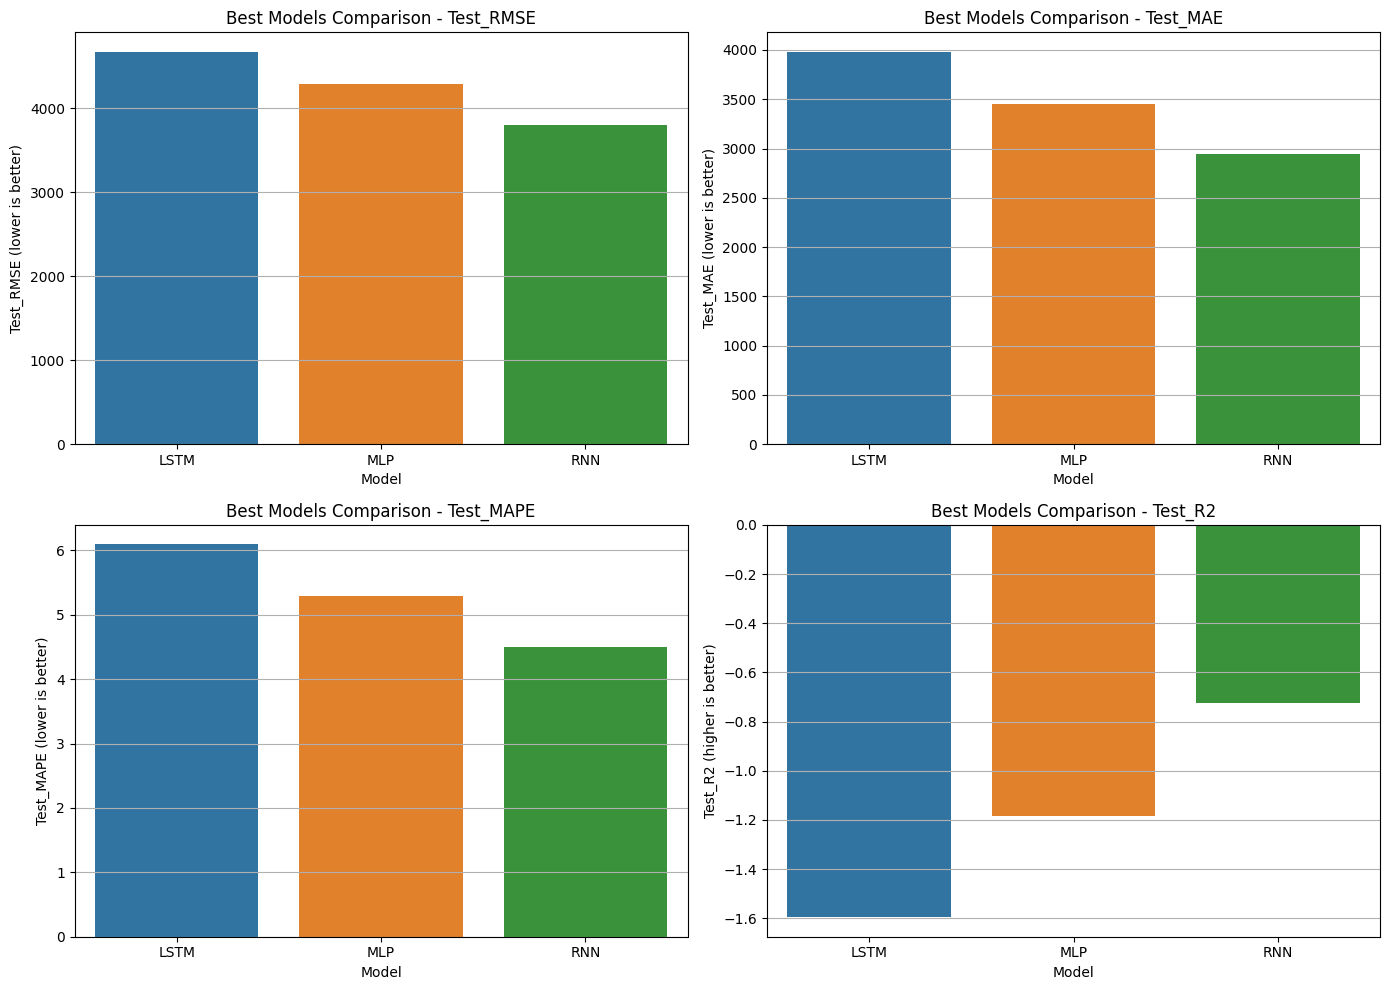

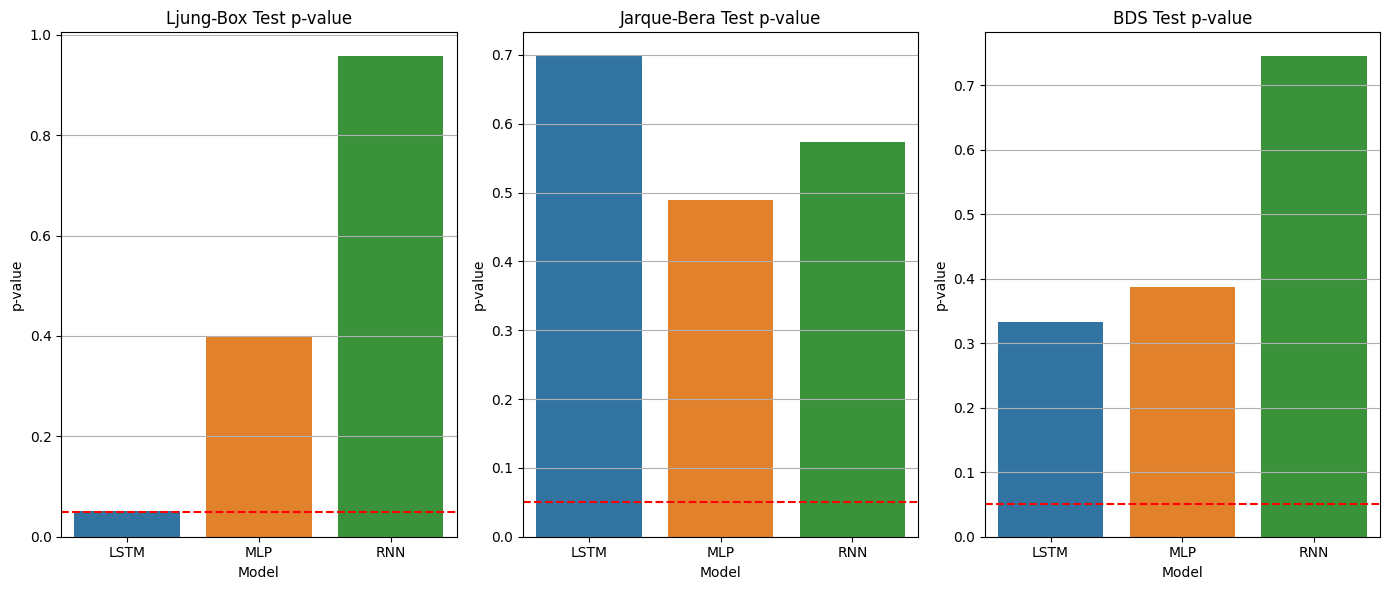


Top 3 Models by Test RMSE:
   Model  Look Back  Forecast Period    Test_RMSE     Test_MAE   Test_R2
13   RNN         21                7  3805.741328  2948.566916 -0.722899
0    MLP          7                7  4287.020486  3453.347162 -1.186213
1    RNN          7                7  4462.163558  3658.052742 -1.368494

Results saved to 'bitcoin_model_results.csv'

Analysis complete!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load and prepare the data
def load_and_prepare_data():
    print("Loading and preparing data...")
    data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
    df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')
    
    # Sort by date in ascending order
    df.sort_index(inplace=True)
    
    # Function to convert volume to number
    def parse_volume_str(vol_str):
        if not isinstance(vol_str, str):
            return vol_str
        vol_str = vol_str.replace(",", "").strip()
        if vol_str.endswith('K'):
            return float(vol_str[:-1]) * 1e3
        elif vol_str.endswith('M'):
            return float(vol_str[:-1]) * 1e6
        elif vol_str.endswith('B'):
            return float(vol_str[:-1]) * 1e9
        else:
            return float(vol_str)
    
    # Apply cleanup function
    df["Vol."] = df["Vol."].apply(parse_volume_str)
    df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
    df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
    df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
    df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
    df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
    
    # Return calculation (Return)
    df["Return"] = df["Price"].pct_change().fillna(0)
    
    # CumulativeReturn Calculation
    df["Cumulative_Return"] = df["Return"].cumsum()
    
    # Volatility Calculation in Rolling Windows
    windows = [7, 14, 21, 28]
    for w in windows:
        df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
    
    print(f"Data preparation complete. DataFrame shape: {df.shape}")
    print("\nFirst few rows of the prepared data:")
    print(df.head())
    
    # Plot a quick summary of the Bitcoin price over time
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['Price'], label='BTC Price')
    plt.title('Bitcoin Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return df

# Define a function to create time series data
def create_dataset(dataset, look_back, predict_forward):
    """
    Convert a time series to a dataset suitable for supervised learning.
    
    Args:
        dataset: Series or array containing the time series data
        look_back: Number of lag observations as input (X)
        predict_forward: Number of observations to predict (Y)
        
    Returns:
        X, y arrays for model training/testing
    """
    X, y = [], []
    for i in range(len(dataset) - look_back - predict_forward + 1):
        X.append(dataset[i:(i + look_back)])
        y.append(dataset[i + look_back:i + look_back + predict_forward])
    return np.array(X), np.array(y)

# Define metrics calculation function
def calculate_metrics(y_true, y_pred):
    """Calculate all required metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    # Calculate MAPE, handling zeros in y_true
    mask = y_true != 0
    if np.any(mask):
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

# Function to calculate statistical tests on residuals
def calculate_tests(residuals):
    """Calculate statistical tests for residuals."""
    # Ljung-Box test for autocorrelation
    lb_test = acorr_ljungbox(residuals, lags=10)
    lb_pvalue = lb_test.iloc[0, 1]  # p-value of lag 1
    
    # Jarque-Bera test for normality
    jb_stat, jb_pvalue = stats.jarque_bera(residuals)
    
    # Alternative to BDS test - use Durbin-Watson statistic
    # The D-W test checks for autocorrelation in residuals
    # Values near 2 indicate no autocorrelation
    from statsmodels.stats.stattools import durbin_watson
    try:
        dw_stat = durbin_watson(residuals)
        # Convert to a pseudo p-value (this is a simplification)
        # DW stat ranges from 0-4, with 2 being ideal
        # Convert this to a "p-value" between 0-1
        # where values closer to 1 suggest randomness
        bds_pvalue = 1 - abs(dw_stat - 2) / 2
    except:
        # Fallback if Durbin-Watson test fails
        bds_pvalue = np.nan
    
    return {
        'Ljung-Box (p-value)': lb_pvalue,
        'Jarque-Bera (p-value)': jb_pvalue,
        'BDS (p-value)': bds_pvalue
    }

# Function to plot residual analysis
def plot_residual_analysis(residuals, title_prefix):
    """Create plots for residual analysis."""
    fig, axes = plt.subplots(3, 1, figsize=(12, 12))
    
    # Residual Series Plot
    axes[0].plot(residuals)
    axes[0].set_title(f'{title_prefix} - Residual Series')
    axes[0].set_xlabel('Index')
    axes[0].set_ylabel('Residual')
    
    # Q-Q Plot
    sm.qqplot(np.array(residuals), line='45', ax=axes[1])
    axes[1].set_title(f'{title_prefix} - QQ Plot')
    
    # ACF Plot
    sm.graphics.tsa.plot_acf(residuals, lags=20, ax=axes[2])
    axes[2].set_title(f'{title_prefix} - ACF of Residuals')
    
    plt.tight_layout()
    plt.show()  # Display the plot
    return fig

# Define model building functions
def build_mlp_model(input_shape, output_shape):
    """Build a Multilayer Perceptron model."""
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_shape,)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(output_shape)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_rnn_model(input_shape, output_shape):
    """Build a Recurrent Neural Network model."""
    model = Sequential([
        SimpleRNN(64, input_shape=(input_shape, 1), return_sequences=True),
        Dropout(0.2),
        SimpleRNN(32),
        Dropout(0.2),
        Dense(output_shape)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm_model(input_shape, output_shape):
    """Build an LSTM model."""
    model = Sequential([
        LSTM(64, input_shape=(input_shape, 1), return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(output_shape)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Main evaluation function
def evaluate_models(df):
    print("\n===== Starting Model Evaluation =====")
    # Target variable to predict
    target_col = 'Price'
    target_data = df[target_col].values.reshape(-1, 1)
    
    # Scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(target_data)
    
    # Define the window sizes to test
    window_sizes = [7, 14, 21, 28]  # Look-back periods
    forecast_periods = [7, 14]  # Reduced forecast periods for quicker execution
    
    # Define model types
    model_types = {
        'MLP': build_mlp_model,
        'RNN': build_rnn_model,
        'LSTM': build_lstm_model
    }
    
    # Store results for each configuration
    all_results = []
    
    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    # Progress counter
    total_combinations = len(window_sizes) * len(forecast_periods) * len(model_types)
    current_combination = 0
    
    # Loop through all combinations
    for look_back in window_sizes:
        for predict_forward in forecast_periods:
            print(f"\n==== Testing look_back={look_back}, predict_forward={predict_forward} ====")
            
            # Create datasets
            X, y = create_dataset(scaled_data, look_back, predict_forward)
            
            # Total sample size
            n_samples = len(X)
            
            # Ensure we have enough data
            if n_samples < 50:  # Arbitrary minimum sample size
                print(f"Skipping look_back={look_back}, predict_forward={predict_forward} due to insufficient data")
                continue
                
            # Split indices for training, validation, and test
            test_size = predict_forward
            val_size = predict_forward
            train_size = n_samples - test_size - val_size
            
            train_indices = range(0, train_size)
            val_indices = range(train_size, train_size + val_size)
            test_indices = range(train_size + val_size, n_samples)
            
            # Create train, validation, test sets
            X_train, y_train = X[train_indices], y[train_indices]
            X_val, y_val = X[val_indices], y[val_indices]
            X_test, y_test = X[test_indices], y[test_indices]
            
            # Reshape for RNN/LSTM models if needed
            X_train_rnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
            X_val_rnn = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
            X_test_rnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
            
            # For each model type
            for model_name, model_builder in model_types.items():
                current_combination += 1
                print(f"\n--- Training {model_name} ({current_combination}/{total_combinations}) ---")
                
                # Build and train the model
                if model_name == 'MLP':
                    model = model_builder(look_back, predict_forward)
                    # Flatten y arrays for MLP
                    y_train_flat = y_train.reshape(y_train.shape[0], -1)
                    y_val_flat = y_val.reshape(y_val.shape[0], -1)
                    y_test_flat = y_test.reshape(y_test.shape[0], -1)
                    
                    # Train the model
                    history = model.fit(
                        X_train, y_train_flat,
                        epochs=50,  # Reduced for quicker execution
                        batch_size=32,
                        validation_data=(X_val, y_val_flat),
                        callbacks=[early_stopping],
                        verbose=1  # Show progress
                    )
                    
                    # Make predictions
                    train_pred = model.predict(X_train)
                    val_pred = model.predict(X_val)
                    test_pred = model.predict(X_test)
                    
                    # Reshape back for evaluation
                    train_pred = train_pred.reshape(train_pred.shape[0], predict_forward, 1)
                    val_pred = val_pred.reshape(val_pred.shape[0], predict_forward, 1)
                    test_pred = test_pred.reshape(test_pred.shape[0], predict_forward, 1)
                    
                else:  # RNN or LSTM
                    model = model_builder(look_back, predict_forward)
                    
                    # Train the model
                    history = model.fit(
                        X_train_rnn, y_train,
                        epochs=50,  # Reduced for quicker execution
                        batch_size=32,
                        validation_data=(X_val_rnn, y_val),
                        callbacks=[early_stopping],
                        verbose=1  # Show progress
                    )
                    
                    # Make predictions
                    train_pred = model.predict(X_train_rnn)
                    val_pred = model.predict(X_val_rnn)
                    test_pred = model.predict(X_test_rnn)
                
                # Inverse transform predictions and actual values
                train_pred_inv = scaler.inverse_transform(train_pred.reshape(-1, 1))
                train_pred_inv = train_pred_inv.reshape(train_pred.shape[0], train_pred.shape[1])

                val_pred_inv = scaler.inverse_transform(val_pred.reshape(-1, 1))
                val_pred_inv = val_pred_inv.reshape(val_pred.shape[0], val_pred.shape[1])

                test_pred_inv = scaler.inverse_transform(test_pred.reshape(-1, 1))
                test_pred_inv = test_pred_inv.reshape(test_pred.shape[0], test_pred.shape[1])

                # Also reshape y data to match
                y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
                y_train_inv = y_train_inv.reshape(y_train.shape[0], y_train.shape[1])

                y_val_inv = scaler.inverse_transform(y_val.reshape(-1, 1))
                y_val_inv = y_val_inv.reshape(y_val.shape[0], y_val.shape[1])

                y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
                y_test_inv = y_test_inv.reshape(y_test.shape[0], y_test.shape[1])

                # Calculate residuals
                train_residuals = (y_train_inv - train_pred_inv).flatten()
                val_residuals = (y_val_inv - val_pred_inv).flatten()
                test_residuals = (y_test_inv - test_pred_inv).flatten()

                # Calculate metrics
                train_metrics = calculate_metrics(y_train_inv.flatten(), train_pred_inv.flatten())
                val_metrics = calculate_metrics(y_val_inv.flatten(), val_pred_inv.flatten())
                test_metrics = calculate_metrics(y_test_inv.flatten(), test_pred_inv.flatten())

                # Calculate statistical tests
                train_tests = calculate_tests(train_residuals)
                val_tests = calculate_tests(val_residuals)
                test_tests = calculate_tests(test_residuals)

                # Display metrics for current model
                print(f"\n----- {model_name} Results with look_back={look_back}, predict_forward={predict_forward} -----")
                print(f"Training metrics: RMSE: {train_metrics['RMSE']:.2f}, MAE: {train_metrics['MAE']:.2f}, R²: {train_metrics['R2']:.4f}")
                print(f"Validation metrics: RMSE: {val_metrics['RMSE']:.2f}, MAE: {val_metrics['MAE']:.2f}, R²: {val_metrics['R2']:.4f}")
                print(f"Test metrics: RMSE: {test_metrics['RMSE']:.2f}, MAE: {test_metrics['MAE']:.2f}, R²: {test_metrics['R2']:.4f}")

                # Plot actual vs predicted for test set
                plt.figure(figsize=(12, 6))
                actual_flattened = y_test_inv.reshape(-1)
                pred_flattened = test_pred_inv.reshape(-1)

                # Only plot a sample if there are many points
                if len(actual_flattened) > 100:
                    plt.plot(actual_flattened[:100], label='Actual')
                    plt.plot(pred_flattened[:100], label='Predicted')
                else:
                    plt.plot(actual_flattened, label='Actual')
                    plt.plot(pred_flattened, label='Predicted')

                plt.title(f'{model_name} with look_back={look_back}, predict_forward={predict_forward} - Test Set')
                plt.legend()
                plt.grid(True)
                plt.show()

                # Plot residual analysis for test set (only for every other combination to avoid too many plots)
                if current_combination % 2 == 0:
                    print("\nTest Set Residual Analysis:")
                    plot_residual_analysis(
                        test_residuals,
                        f"{model_name} (Test) - Window {look_back} - Forecast {predict_forward}"
                    )

                # Store results for later comparison
                model_result = {
                    'Model': model_name,
                    'Look Back': look_back,
                    'Forecast Period': predict_forward,
                    'Train_RMSE': train_metrics['RMSE'],
                    'Val_RMSE': val_metrics['RMSE'],
                    'Test_RMSE': test_metrics['RMSE'],
                    'Train_MAE': train_metrics['MAE'],
                    'Val_MAE': val_metrics['MAE'],
                    'Test_MAE': test_metrics['MAE'],
                    'Train_MAPE': train_metrics['MAPE'],
                    'Val_MAPE': val_metrics['MAPE'],
                    'Test_MAPE': test_metrics['MAPE'],
                    'Train_R2': train_metrics['R2'],
                    'Val_R2': val_metrics['R2'],
                    'Test_R2': test_metrics['R2'],
                    'LB_pvalue': test_tests['Ljung-Box (p-value)'],
                    'JB_pvalue': test_tests['Jarque-Bera (p-value)'],
                    'BDS_pvalue': test_tests['BDS (p-value)']
                }
                all_results.append(model_result)

                # Create a comparison dataframe for all models so far
                results_df = pd.DataFrame(all_results)
                if len(results_df) > 1:
                    print("\nCurrent Model Comparison (sorted by Test RMSE):")
                    sorted_results = results_df.sort_values('Test_RMSE')
                    print(sorted_results[['Model', 'Look Back', 'Forecast Period', 'Test_RMSE', 'Test_MAE', 'Test_R2']])

                    # After every few models, show a visual comparison
                    if current_combination % 3 == 0 and len(results_df) >= 3:
                        plt.figure(figsize=(12, 6))
                        sns.barplot(x='Model', y='Test_RMSE', hue='Look Back', 
                                   data=results_df)
                        plt.title('Test RMSE Comparison')
                        plt.ylabel('RMSE')
                        plt.xticks(rotation=45)
                        plt.tight_layout()
                        plt.show()

    # Create a DataFrame from all results
    final_results_df = pd.DataFrame(all_results)
        
    # Return the results dataframe for further analysis
    return final_results_df

# Function to visualize final results
def visualize_final_results(results_df):
    """Create comprehensive visualizations for final model comparison."""
    print("\n===== Final Results Visualization =====")
    
    if len(results_df) < 1:
        print("No results to visualize!")
        return
        
    # 1. Overall comparison of Test RMSE by model type and look-back window
    plt.figure(figsize=(14, 8))
    sns.barplot(x='Model', y='Test_RMSE', hue='Look Back', data=results_df)
    plt.title('Test RMSE by Model Type and Look-back Window')
    plt.ylabel('RMSE (lower is better)')
    plt.xlabel('Model Type')
    plt.legend(title='Look Back Days')
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()
    
    # 2. Heatmap comparing test RMSE across all configurations
    plt.figure(figsize=(12, 8))
    pivot_table = results_df.pivot_table(
        values='Test_RMSE',
        index=['Model', 'Look Back'],
        columns=['Forecast Period']
    )
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu_r")
    plt.title('Test RMSE Across Different Configurations')
    plt.tight_layout()
    plt.show()
    
    # 3. Compare different metrics for the best models of each type
    best_models = results_df.loc[results_df.groupby('Model')['Test_RMSE'].idxmin()]
    
    metrics = ['Test_RMSE', 'Test_MAE', 'Test_MAPE', 'Test_R2']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        sns.barplot(x='Model', y=metric, data=best_models, ax=ax)
        ax.set_title(f'Best Models Comparison - {metric}')
        ax.grid(True, axis='y')
        if metric != 'Test_R2':
            ax.set_ylabel(f'{metric} (lower is better)')
        else:
            ax.set_ylabel(f'{metric} (higher is better)')
    
    plt.tight_layout()
    plt.show()
    
    # 4. Statistical test results visualization
    plt.figure(figsize=(14, 6))
    
    # Ljung-Box test
    plt.subplot(1, 3, 1)
    sns.barplot(x='Model', y='LB_pvalue', data=best_models)
    plt.axhline(y=0.05, color='r', linestyle='--')
    plt.title('Ljung-Box Test p-value')
    plt.ylabel('p-value')
    plt.grid(True, axis='y')
    
    # Jarque-Bera test
    plt.subplot(1, 3, 2)
    sns.barplot(x='Model', y='JB_pvalue', data=best_models)
    plt.axhline(y=0.05, color='r', linestyle='--')
    plt.title('Jarque-Bera Test p-value')
    plt.ylabel('p-value')
    plt.grid(True, axis='y')
    
    # BDS test
    plt.subplot(1, 3, 3)
    sns.barplot(x='Model', y='BDS_pvalue', data=best_models)
    plt.axhline(y=0.05, color='r', linestyle='--')
    plt.title('BDS Test p-value')
    plt.ylabel('p-value')
    plt.grid(True, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # 5. Summary table of top 3 models
    top_models = results_df.sort_values('Test_RMSE').head(3)
    print("\nTop 3 Models by Test RMSE:")
    display_cols = ['Model', 'Look Back', 'Forecast Period', 'Test_RMSE', 'Test_MAE', 'Test_R2']
    print(top_models[display_cols])
    
    return best_models

# Main function to run the entire analysis
def main():
    """Run the entire analysis pipeline with interactive visualizations."""
    print("Starting Enhanced Bitcoin Price Analysis Pipeline...")
    
    # Load and prepare data
    df = load_and_prepare_data()
    
    # Evaluate models
    results_df = evaluate_models(df)
    
    # Visualize final results
    best_models = visualize_final_results(results_df)
    
    # Save results
    try:
        results_df.to_csv('bitcoin_model_results.csv', index=False)
        print("\nResults saved to 'bitcoin_model_results.csv'")
    except:
        print("\nCouldn't save results to CSV file")
    
    print("\nAnalysis complete!")
    
    return results_df, best_models

# Run the analysis if this is the main script
if __name__ == "__main__":
    results_df, best_models = main()